# Stage 7 — Advanced Model Comparison and Controlled Selection

## Objective

Evaluate whether nonlinear tree-based models provide a reliable improvement over the interpretable logistic-regression baseline when predicting whether an individual pass rusher will generate pressure after the snap.

A pass rusher is a defender attempting to reach the quarterback. A pressure occurs when the defender records a hurry, hit, or sack.

## Methodological design

- Analytical unit: one pass rusher per passing play.
- Target: `pressure = pff_hurry OR pff_hit OR pff_sack`.
- Predictors: 50 numerical variables and one categorical variable observed at the snap.
- Primary metric: Average Precision.
- Secondary metrics: ROC-AUC and Log Loss.
- Training period: actual NFL weeks 1–6.
- Validation period: actual NFL week 7.
- Final test period: actual NFL week 8, kept completely untouched.
- No classification threshold is selected in this stage.

Hyperparameters are tuned through expanding temporal validation:

1. Train on weeks 1–3 and validate on week 4.
2. Train on weeks 1–4 and validate on week 5.
3. Train on weeks 1–5 and validate on week 6.

All preprocessing is fitted inside each model pipeline. Player and play identifiers, target components, audit-only fields, future events, and post-snap information are excluded from the predictors.

## Candidate models

The selected Stage 6 logistic-regression pipeline is compared against:

- `HistGradientBoostingClassifier`
- `ExtraTreesClassifier`

Each advanced family receives a controlled search of 12 configurations. Model selection prioritizes Average Precision while considering probability quality, temporal stability, uncertainty, interpretability, and additional model complexity.

All findings represent predictive associations and must not be interpreted as causal effects.

In [1]:
from pathlib import Path
from importlib.util import find_spec
import platform
import sys

import joblib
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier


RANDOM_STATE = 42

# Localizar la raíz mediante un artefacto cerrado de la Etapa 4.
current_path = Path.cwd().resolve()
candidate_roots = [current_path, *current_path.parents]

PROJECT_ROOT = next(
    (
        path
        for path in candidate_roots
        if (
            path
            / "data"
            / "processed"
            / "pass_rush_analytical_table.parquet"
        ).is_file()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "No fue posible localizar la raíz del proyecto desde "
        f"{current_path}."
    )

ARTIFACT_PATHS = {
    "analytical_table": (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "pass_rush_analytical_table.parquet"
    ),
    "column_inventory": (
        PROJECT_ROOT
        / "reports"
        / "analytical_table_column_inventory.csv"
    ),
    "stage6_model": (
        PROJECT_ROOT
        / "models"
        / "logistic_regression_stage6.joblib"
    ),
    "stage6_results": (
        PROJECT_ROOT
        / "reports"
        / "stage6_baseline_model_results.csv"
    ),
    "stage6_quality_report": (
        PROJECT_ROOT
        / "reports"
        / "stage6_quality_report.csv"
    ),
}

environment_audit = pd.DataFrame(
    {
        "component": [
            "Python",
            "Operating system",
            "NumPy",
            "pandas",
            "scikit-learn",
            "joblib",
            "Project root",
        ],
        "value": [
            sys.version.split()[0],
            platform.platform(),
            np.__version__,
            pd.__version__,
            sklearn.__version__,
            joblib.__version__,
            str(PROJECT_ROOT),
        ],
    }
)

artifact_audit = pd.DataFrame(
    [
        {
            "artifact": name,
            "exists": path.is_file(),
            "path": str(path),
        }
        for name, path in ARTIFACT_PATHS.items()
    ]
)

optional_dependency_audit = pd.DataFrame(
    {
        "package": ["xgboost", "lightgbm", "catboost"],
        "installed": [
            find_spec("xgboost") is not None,
            find_spec("lightgbm") is not None,
            find_spec("catboost") is not None,
        ],
        "approved_for_stage7": [False, False, False],
    }
)

display(environment_audit)
display(artifact_audit)
display(optional_dependency_audit)

if not artifact_audit["exists"].all():
    missing = artifact_audit.loc[
        ~artifact_audit["exists"], "artifact"
    ].tolist()
    raise FileNotFoundError(
        f"Faltan artefactos obligatorios: {missing}"
    )

print("Stage 7 environment audit: PASS")
print("No dataset rows were loaded; week 8 remains untouched.")

,component,value
0,Python,3.14.0
1,Operating system,Windows-11-10.0.26200-SP0
2,NumPy,2.5.2
3,pandas,3.0.5
4,scikit-learn,1.9.0
5,joblib,1.5.3
6,Project root,C:\Users\yvett\OneDrive\Documentos\Francisco F...


,artifact,exists,path
0,analytical_table,True,C:\Users\yvett\OneDrive\Documentos\Francisco F...
1,column_inventory,True,C:\Users\yvett\OneDrive\Documentos\Francisco F...
2,stage6_model,True,C:\Users\yvett\OneDrive\Documentos\Francisco F...
3,stage6_results,True,C:\Users\yvett\OneDrive\Documentos\Francisco F...
4,stage6_quality_report,True,C:\Users\yvett\OneDrive\Documentos\Francisco F...


,package,installed,approved_for_stage7
0,xgboost,False,False
1,lightgbm,False,False
2,catboost,False,False


Stage 7 environment audit: PASS
No dataset rows were loaded; week 8 remains untouched.


In [2]:
# Semanas autorizadas para desarrollo durante la Etapa 7.
TRAIN_WEEKS = tuple(range(1, 7))
VALIDATION_WEEKS = (7,)
DEVELOPMENT_WEEKS = TRAIN_WEEKS + VALIDATION_WEEKS

# El filtro evita materializar la semana 8 en el DataFrame.
development_df = pd.read_parquet(
    ARTIFACT_PATHS["analytical_table"],
    engine="pyarrow",
    filters=[("actual_week", "in", list(DEVELOPMENT_WEEKS))],
)

expected_splits = {
    "train": {
        "weeks": TRAIN_WEEKS,
        "rows": 27_950,
        "plays": 6_587,
        "positives": 3_283,
    },
    "validation": {
        "weeks": VALIDATION_WEEKS,
        "rows": 3_865,
        "plays": 913,
        "positives": 427,
    },
}

split_records = []
split_subsets = {}

for split_name, expected in expected_splits.items():
    subset = development_df.loc[
        development_df["actual_week"].isin(expected["weeks"])
    ].copy()

    split_subsets[split_name] = subset

    split_records.append(
        {
            "split": split_name,
            "weeks": ", ".join(map(str, expected["weeks"])),
            "rows": len(subset),
            "plays": len(
                subset[["gameId", "playId"]].drop_duplicates()
            ),
            "positives": int(subset["pressure"].sum()),
            "prevalence_pct": 100 * subset["pressure"].mean(),
        }
    )

split_audit = pd.DataFrame(split_records)

observed_weeks = sorted(
    development_df["actual_week"].astype(int).unique().tolist()
)

duplicate_units = development_df.duplicated(
    subset=["gameId", "playId", "pass_rusher_nfl_id"]
).sum()

train_play_keys = set(
    map(
        tuple,
        split_subsets["train"][["gameId", "playId"]]
        .drop_duplicates()
        .to_numpy(),
    )
)

validation_play_keys = set(
    map(
        tuple,
        split_subsets["validation"][["gameId", "playId"]]
        .drop_duplicates()
        .to_numpy(),
    )
)

shared_plays = train_play_keys.intersection(validation_play_keys)

assert observed_weeks == list(DEVELOPMENT_WEEKS)
assert 8 not in observed_weeks
assert development_df.shape == (31_815, 70)
assert set(development_df["pressure"].unique()).issubset({0, 1})
assert duplicate_units == 0
assert len(shared_plays) == 0

for record in split_records:
    expected = expected_splits[record["split"]]
    assert record["rows"] == expected["rows"]
    assert record["plays"] == expected["plays"]
    assert record["positives"] == expected["positives"]

print(split_audit.round({"prevalence_pct": 3}))

print(f"Observed development weeks: {observed_weeks}")
print(f"Duplicate analytical units: {duplicate_units}")
print(f"Shared train-validation plays: {len(shared_plays)}")
print("Development data validation: PASS")
print("Week 8 was not materialized.")

        split             weeks   rows  plays  positives  prevalence_pct
0       train  1, 2, 3, 4, 5, 6  27950   6587       3283          11.746
1  validation                 7   3865    913        427          11.048
Observed development weeks: [1, 2, 3, 4, 5, 6, 7]
Duplicate analytical units: 0
Shared train-validation plays: 0
Development data validation: PASS
Week 8 was not materialized.


In [3]:
column_inventory = pd.read_csv(
    ARTIFACT_PATHS["column_inventory"]
)

inventory_columns = set(column_inventory["column"])
analytical_columns = set(development_df.columns)

missing_from_inventory = sorted(
    analytical_columns - inventory_columns
)
unexpected_in_inventory = sorted(
    inventory_columns - analytical_columns
)

inventory_profile = pd.DataFrame(
    {
        "field": column_inventory.columns,
        "dtype": [
            str(column_inventory[column].dtype)
            for column in column_inventory.columns
        ],
        "non_null": [
            int(column_inventory[column].notna().sum())
            for column in column_inventory.columns
        ],
        "unique_values": [
            int(column_inventory[column].nunique(dropna=True))
            for column in column_inventory.columns
        ],
        "sample_values": [
            " | ".join(
                column_inventory[column]
                .dropna()
                .astype(str)
                .drop_duplicates()
                .head(12)
                .tolist()
            )
            for column in column_inventory.columns
        ],
    }
)

assert column_inventory.shape == (70, 7)
assert "column" in column_inventory.columns
assert column_inventory["column"].notna().all()
assert column_inventory["column"].is_unique
assert not missing_from_inventory
assert not unexpected_in_inventory

print(inventory_profile)
print(column_inventory.head(12))

print(f"Inventory shape: {column_inventory.shape}")
print(f"Missing columns in inventory: {missing_from_inventory}")
print(f"Unexpected inventory columns: {unexpected_in_inventory}")
print(
    "Inventory order matches analytical table:",
    column_inventory["column"].tolist()
    == development_df.columns.tolist(),
)
print("Column inventory integrity: PASS")

             field  dtype  non_null  unique_values  \
0  column_position  int64        70             70   
1           column    str        70             70   
2      column_role    str        70              6   
3            dtype    str        70              6   
4          missing  int64        70              1   
5    unique_values  int64        70             66   
6   model_eligible   bool        70              2   

                                       sample_values  
0   1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12  
1  actual_week | gameId | playId | pass_rusher_nf...  
2  split_metadata | identifier_metadata | audit_o...  
3       Int64 | int64 | str | float64 | int16 | int8  
4                                                  0  
5  8 | 122 | 3754 | 698 | 60 | 399 | 2 | 10906 | ...  
6                                       False | True  
    column_position                   column          column_role    dtype  \
0                 1              actual_week     

In [4]:
from pandas.api.types import is_numeric_dtype


TARGET_COLUMN = "pressure"

KNOWN_FORBIDDEN_COLUMNS = {
    # Target y control temporal.
    "pressure",
    "actual_week",
    "has_valid_manual_snap",

    # Identificadores.
    "gameId",
    "playId",
    "pass_rusher_nfl_id",
    "quarterback_nfl_id",
    "nearest_blocker_nfl_id",

    # Coordenadas del balón no aprobadas.
    "football_y",
    "football_y_norm",

    # Resultados y anotaciones PFF posteriores al snap.
    "pff_hit",
    "pff_hurry",
    "pff_sack",
    "pff_beatenByDefender",
    "pff_hitAllowed",
    "pff_hurryAllowed",
    "pff_sackAllowed",
    "pff_nflIdBlockedPlayer",
    "pff_blockType",
    "pff_backFieldBlock",
}

eligible_inventory = (
    column_inventory.loc[column_inventory["model_eligible"]]
    .sort_values("column_position")
    .reset_index(drop=True)
)

feature_columns = eligible_inventory["column"].tolist()

numeric_features = [
    column
    for column in feature_columns
    if is_numeric_dtype(development_df[column])
]

categorical_features = [
    column
    for column in feature_columns
    if not is_numeric_dtype(development_df[column])
]

inventory_exclusions = set(
    column_inventory.loc[
        ~column_inventory["model_eligible"],
        "column",
    ]
)

all_forbidden_columns = (
    KNOWN_FORBIDDEN_COLUMNS | inventory_exclusions
)

forbidden_predictors = sorted(
    set(feature_columns) & all_forbidden_columns
)

missing_feature_values = int(
    development_df[feature_columns].isna().sum().sum()
)

numeric_array = development_df[numeric_features].to_numpy(
    dtype="float64"
)
non_finite_numeric_values = int(
    (~np.isfinite(numeric_array)).sum()
)

role_summary = (
    column_inventory
    .groupby(
        ["column_role", "model_eligible"],
        dropna=False,
    )
    .size()
    .rename("columns")
    .reset_index()
    .sort_values(
        ["model_eligible", "column_role"],
        ascending=[False, True],
    )
)

contract_summary = pd.DataFrame(
    {
        "feature_type": [
            "numeric",
            "categorical",
            "total",
        ],
        "count": [
            len(numeric_features),
            len(categorical_features),
            len(feature_columns),
        ],
    }
)

assert len(feature_columns) == 51
assert len(numeric_features) == 50
assert categorical_features == ["rusher_position_lined_up"]
assert len(set(feature_columns)) == 51
assert forbidden_predictors == []
assert missing_feature_values == 0
assert non_finite_numeric_values == 0
assert TARGET_COLUMN not in feature_columns

display(role_summary)
display(contract_summary)

print(f"Categorical predictors: {categorical_features}")
print(f"Forbidden predictors detected: {forbidden_predictors}")
print(f"Missing feature values: {missing_feature_values}")
print(
    "Non-finite numeric values:",
    non_finite_numeric_values,
)
print(
    "Feature order preserved:",
    feature_columns
    == eligible_inventory["column"].tolist(),
)
print("Stage 7 feature contract: PASS")

,column_role,model_eligible,columns
1,categorical_predictor,True,1
3,numeric_predictor,True,50
0,audit_only,False,12
2,identifier_metadata,False,5
4,split_metadata,False,1
5,target,False,1


,feature_type,count
0,numeric,50
1,categorical,1
2,total,51


Categorical predictors: ['rusher_position_lined_up']
Forbidden predictors detected: []
Missing feature values: 0
Non-finite numeric values: 0
Feature order preserved: True
Stage 7 feature contract: PASS


In [5]:
METADATA_COLUMNS = [
    "actual_week",
    "gameId",
    "playId",
    "pass_rusher_nfl_id",
]

train_rows = (
    development_df.loc[
        development_df["actual_week"].isin(TRAIN_WEEKS)
    ]
    .copy()
    .reset_index(drop=True)
)

validation_rows = (
    development_df.loc[
        development_df["actual_week"].isin(
            VALIDATION_WEEKS
        )
    ]
    .copy()
    .reset_index(drop=True)
)

X_train = train_rows.loc[:, feature_columns].copy()
y_train = (
    train_rows[TARGET_COLUMN]
    .astype("int8")
    .copy()
)

X_validation = validation_rows.loc[
    :,
    feature_columns,
].copy()

y_validation = (
    validation_rows[TARGET_COLUMN]
    .astype("int8")
    .copy()
)

train_metadata = train_rows.loc[
    :,
    METADATA_COLUMNS,
].copy()

validation_metadata = validation_rows.loc[
    :,
    METADATA_COLUMNS,
].copy()

train_categories = set(
    X_train[categorical_features[0]]
    .dropna()
    .astype(str)
    .unique()
)

validation_categories = set(
    X_validation[categorical_features[0]]
    .dropna()
    .astype(str)
    .unique()
)

unseen_validation_categories = sorted(
    validation_categories - train_categories
)

matrix_audit = pd.DataFrame(
    {
        "split": ["train", "validation"],
        "rows": [
            len(X_train),
            len(X_validation),
        ],
        "predictors": [
            X_train.shape[1],
            X_validation.shape[1],
        ],
        "positives": [
            int(y_train.sum()),
            int(y_validation.sum()),
        ],
        "prevalence_pct": [
            100 * y_train.mean(),
            100 * y_validation.mean(),
        ],
        "missing_values": [
            int(X_train.isna().sum().sum()),
            int(X_validation.isna().sum().sum()),
        ],
    }
)

assert X_train.shape == (27_950, 51)
assert X_validation.shape == (3_865, 51)
assert y_train.shape == (27_950,)
assert y_validation.shape == (3_865,)

assert int(y_train.sum()) == 3_283
assert int(y_validation.sum()) == 427

assert X_train.columns.tolist() == feature_columns
assert X_validation.columns.tolist() == feature_columns

assert X_train.isna().sum().sum() == 0
assert X_validation.isna().sum().sum() == 0

assert set(y_train.unique()).issubset({0, 1})
assert set(y_validation.unique()).issubset({0, 1})

assert train_metadata["actual_week"].isin(
    TRAIN_WEEKS
).all()

assert validation_metadata["actual_week"].isin(
    VALIDATION_WEEKS
).all()

assert "actual_week" not in X_train.columns
assert TARGET_COLUMN not in X_train.columns
assert not (set(X_train.columns) & all_forbidden_columns)

assert "X_test" not in globals()
assert "y_test" not in globals()

display(
    matrix_audit.round(
        {"prevalence_pct": 3}
    )
)

print(
    "Unseen validation categories:",
    unseen_validation_categories,
)
print(
    "Train feature order equals validation:",
    X_train.columns.tolist()
    == X_validation.columns.tolist(),
)
print("Train/validation matrices: PASS")
print("X_test and y_test do not exist.")

,split,rows,predictors,positives,prevalence_pct,missing_values
0,train,27950,51,3283,11.746,0
1,validation,3865,51,427,11.048,0


Unseen validation categories: []
Train feature order equals validation: True
Train/validation matrices: PASS
X_test and y_test do not exist.


In [6]:
TEMPORAL_FOLD_DEFINITIONS = [
    {
        "fold": "fold_1",
        "train_weeks": (1, 2, 3),
        "validation_week": 4,
    },
    {
        "fold": "fold_2",
        "train_weeks": (1, 2, 3, 4),
        "validation_week": 5,
    },
    {
        "fold": "fold_3",
        "train_weeks": (1, 2, 3, 4, 5),
        "validation_week": 6,
    },
]

temporal_cv_splits = []
temporal_cv_records = []
validation_index_sets = []

for definition in TEMPORAL_FOLD_DEFINITIONS:
    fold_name = definition["fold"]
    fold_train_weeks = definition["train_weeks"]
    fold_validation_week = definition["validation_week"]

    fold_train_indices = np.flatnonzero(
        train_metadata["actual_week"]
        .isin(fold_train_weeks)
        .to_numpy()
    )

    fold_validation_indices = np.flatnonzero(
        train_metadata["actual_week"]
        .eq(fold_validation_week)
        .to_numpy()
    )

    fold_train_metadata = train_metadata.iloc[
        fold_train_indices
    ]

    fold_validation_metadata = train_metadata.iloc[
        fold_validation_indices
    ]

    fold_train_play_keys = set(
        map(
            tuple,
            fold_train_metadata[
                ["gameId", "playId"]
            ]
            .drop_duplicates()
            .to_numpy(),
        )
    )

    fold_validation_play_keys = set(
        map(
            tuple,
            fold_validation_metadata[
                ["gameId", "playId"]
            ]
            .drop_duplicates()
            .to_numpy(),
        )
    )

    shared_fold_plays = (
        fold_train_play_keys
        & fold_validation_play_keys
    )

    assert len(fold_train_indices) > 0
    assert len(fold_validation_indices) > 0
    assert max(fold_train_weeks) < fold_validation_week
    assert len(shared_fold_plays) == 0

    assert (
        y_train.iloc[fold_train_indices].nunique()
        == 2
    )
    assert (
        y_train.iloc[fold_validation_indices].nunique()
        == 2
    )

    temporal_cv_splits.append(
        (
            fold_train_indices,
            fold_validation_indices,
        )
    )

    validation_index_sets.append(
        set(fold_validation_indices)
    )

    temporal_cv_records.append(
        {
            "fold": fold_name,
            "train_weeks": ", ".join(
                map(str, fold_train_weeks)
            ),
            "validation_week": fold_validation_week,
            "train_rows": len(fold_train_indices),
            "validation_rows": len(
                fold_validation_indices
            ),
            "train_plays": len(
                fold_train_play_keys
            ),
            "validation_plays": len(
                fold_validation_play_keys
            ),
            "train_positives": int(
                y_train.iloc[
                    fold_train_indices
                ].sum()
            ),
            "validation_positives": int(
                y_train.iloc[
                    fold_validation_indices
                ].sum()
            ),
            "validation_prevalence_pct": (
                100
                * y_train.iloc[
                    fold_validation_indices
                ].mean()
            ),
            "shared_plays": len(
                shared_fold_plays
            ),
        }
    )

for first_index, first_set in enumerate(
    validation_index_sets
):
    for second_set in validation_index_sets[
        first_index + 1:
    ]:
        assert first_set.isdisjoint(second_set)

temporal_cv_audit = pd.DataFrame(
    temporal_cv_records
)

assert len(temporal_cv_splits) == 3
assert temporal_cv_audit[
    "validation_week"
].tolist() == [4, 5, 6]
assert temporal_cv_audit["shared_plays"].sum() == 0
assert 7 not in temporal_cv_audit[
    "validation_week"
].tolist()
assert 8 not in train_metadata[
    "actual_week"
].unique()

display(
    temporal_cv_audit.round(
        {"validation_prevalence_pct": 3}
    )
)

print(
    "Temporal validation weeks:",
    temporal_cv_audit[
        "validation_week"
    ].tolist(),
)
print("Week 7 used during tuning: False")
print("Week 8 present in training data: False")
print("Temporal CV construction: PASS")

,fold,train_weeks,validation_week,train_rows,validation_rows,train_plays,validation_plays,train_positives,validation_positives,validation_prevalence_pct,shared_plays
0,fold_1,"1, 2, 3",4,14295,4733,3373,1108,1725,557,11.768,0
1,fold_2,"1, 2, 3, 4",5,19028,4681,4481,1105,2282,528,11.280,0
2,fold_3,"1, 2, 3, 4, 5",6,23709,4241,5586,1001,2810,473,11.153,0


Temporal validation weeks: [4, 5, 6]
Week 7 used during tuning: False
Week 8 present in training data: False
Temporal CV construction: PASS


In [7]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                dtype=np.float64,
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# Auditoría segura usando exclusivamente el primer fold.
audit_train_indices, audit_validation_indices = (
    temporal_cv_splits[0]
)

audit_preprocessor = clone(tree_preprocessor)

X_audit_train_transformed = (
    audit_preprocessor.fit_transform(
        X_train.iloc[audit_train_indices]
    )
)

X_audit_validation_transformed = (
    audit_preprocessor.transform(
        X_train.iloc[audit_validation_indices]
    )
)

transformed_feature_names = (
    audit_preprocessor.get_feature_names_out()
)

audit_train_categories = set(
    X_train.iloc[audit_train_indices][
        categorical_features[0]
    ]
    .astype(str)
    .unique()
)

audit_validation_categories = set(
    X_train.iloc[audit_validation_indices][
        categorical_features[0]
    ]
    .astype(str)
    .unique()
)

unseen_audit_categories = sorted(
    audit_validation_categories
    - audit_train_categories
)

preprocessing_audit = pd.DataFrame(
    {
        "dataset": [
            "fold_1_train",
            "fold_1_validation",
        ],
        "input_rows": [
            len(audit_train_indices),
            len(audit_validation_indices),
        ],
        "input_features": [
            X_train.shape[1],
            X_train.shape[1],
        ],
        "output_rows": [
            X_audit_train_transformed.shape[0],
            X_audit_validation_transformed.shape[0],
        ],
        "output_features": [
            X_audit_train_transformed.shape[1],
            X_audit_validation_transformed.shape[1],
        ],
        "non_finite_values": [
            int(
                (
                    ~np.isfinite(
                        X_audit_train_transformed
                    )
                ).sum()
            ),
            int(
                (
                    ~np.isfinite(
                        X_audit_validation_transformed
                    )
                ).sum()
            ),
        ],
    }
)

assert X_audit_train_transformed.shape[0] == len(
    audit_train_indices
)
assert X_audit_validation_transformed.shape[0] == len(
    audit_validation_indices
)

assert (
    X_audit_train_transformed.shape[1]
    == X_audit_validation_transformed.shape[1]
)

assert (
    len(transformed_feature_names)
    == X_audit_train_transformed.shape[1]
)

assert len(set(transformed_feature_names)) == len(
    transformed_feature_names
)

assert np.isfinite(
    X_audit_train_transformed
).all()

assert np.isfinite(
    X_audit_validation_transformed
).all()

# El preprocesador reutilizable continúa sin ajustar.
assert not hasattr(
    tree_preprocessor,
    "transformers_",
)

display(preprocessing_audit)

print(
    "Transformed feature count:",
    len(transformed_feature_names),
)
print(
    "Categorical levels learned in fold 1:",
    len(audit_train_categories),
)
print(
    "Unseen categories in fold 1 validation:",
    unseen_audit_categories,
)
print(
    "Reusable preprocessor remains unfitted:",
    not hasattr(tree_preprocessor, "transformers_"),
)
print("Tree preprocessing audit: PASS")

,dataset,input_rows,input_features,output_rows,output_features,non_finite_values
0,fold_1_train,14295,51,14295,76,0
1,fold_1_validation,4733,51,4733,76,0


Transformed feature count: 76
Categorical levels learned in fold 1: 26
Unseen categories in fold 1 validation: ['FS']
Reusable preprocessor remains unfitted: True
Tree preprocessing audit: PASS


In [8]:
from sklearn.metrics import (
    average_precision_score,
    log_loss,
    roc_auc_score,
)


PRIMARY_METRIC = "average_precision"
SECONDARY_METRICS = (
    "roc_auc",
    "log_loss",
)

metric_policy = pd.DataFrame(
    {
        "metric": [
            "Average Precision",
            "ROC-AUC",
            "Log Loss",
        ],
        "direction": [
            "higher_is_better",
            "higher_is_better",
            "lower_is_better",
        ],
        "role": [
            "primary",
            "secondary",
            "secondary",
        ],
        "requires_threshold": [
            False,
            False,
            False,
        ],
    }
)


def evaluate_probabilities(
    y_true,
    positive_probabilities,
    model_name,
    split_name,
):
    """Evaluate binary probabilities without choosing a threshold."""

    y_array = np.asarray(
        y_true,
        dtype=np.int8,
    ).reshape(-1)

    probability_array = np.asarray(
        positive_probabilities,
        dtype=np.float64,
    ).reshape(-1)

    if len(y_array) != len(probability_array):
        raise ValueError(
            "Targets and probabilities have different lengths."
        )

    if set(np.unique(y_array)) != {0, 1}:
        raise ValueError(
            "The target must contain both binary classes."
        )

    if not np.isfinite(probability_array).all():
        raise ValueError(
            "Probabilities contain non-finite values."
        )

    if (
        (probability_array < 0)
        | (probability_array > 1)
    ).any():
        raise ValueError(
            "Probabilities must remain between 0 and 1."
        )

    return {
        "model": model_name,
        "split": split_name,
        "rows": len(y_array),
        "positives": int(y_array.sum()),
        "prevalence": float(y_array.mean()),
        "average_precision": float(
            average_precision_score(
                y_array,
                probability_array,
            )
        ),
        "roc_auc": float(
            roc_auc_score(
                y_array,
                probability_array,
            )
        ),
        "log_loss": float(
            log_loss(
                y_array,
                probability_array,
                labels=[0, 1],
            )
        ),
    }


# Prueba controlada utilizada también en la Etapa 6.
artificial_y = np.array(
    [0, 0, 1, 1],
    dtype=np.int8,
)

artificial_probabilities = np.array(
    [0.10, 0.30, 0.70, 0.90],
    dtype=np.float64,
)

artificial_result = evaluate_probabilities(
    y_true=artificial_y,
    positive_probabilities=artificial_probabilities,
    model_name="artificial_perfect_ranking",
    split_name="unit_test",
)

assert np.isclose(
    artificial_result["average_precision"],
    1.0,
)
assert np.isclose(
    artificial_result["roc_auc"],
    1.0,
)
assert np.isclose(
    artificial_result["log_loss"],
    0.2310177298,
    atol=1e-10,
)

display(metric_policy)
display(
    pd.DataFrame([artificial_result]).round(6)
)

print(
    f"Primary metric: {PRIMARY_METRIC}"
)
print(
    "Threshold selected: False"
)
print(
    "Probability evaluation function: PASS"
)

,metric,direction,role,requires_threshold
0,Average Precision,higher_is_better,primary,False
1,ROC-AUC,higher_is_better,secondary,False
2,Log Loss,lower_is_better,secondary,False


,model,split,rows,positives,prevalence,average_precision,roc_auc,log_loss
0,artificial_perfect_ranking,unit_test,4,2,0.5,1.0,1.0,0.231018


Primary metric: average_precision
Threshold selected: False
Probability evaluation function: PASS


In [9]:
stage6_results = pd.read_csv(
    ARTIFACT_PATHS["stage6_results"]
)

stage6_pipeline = joblib.load(
    ARTIFACT_PATHS["stage6_model"]
)

if not hasattr(
    stage6_pipeline,
    "feature_names_in_",
):
    raise AttributeError(
        "The Stage 6 pipeline does not preserve input feature names."
    )

stage6_feature_order = (
    stage6_pipeline.feature_names_in_.tolist()
)

missing_in_stage6_pipeline = sorted(
    set(feature_columns)
    - set(stage6_feature_order)
)

unexpected_in_stage6_pipeline = sorted(
    set(stage6_feature_order)
    - set(feature_columns)
)

feature_order_comparison = pd.DataFrame(
    {
        "position": range(1, len(feature_columns) + 1),
        "current_contract": feature_columns,
        "stage6_pipeline": stage6_feature_order,
    }
)

feature_order_comparison["same_position"] = (
    feature_order_comparison["current_contract"]
    == feature_order_comparison["stage6_pipeline"]
)

# Para el baseline usamos exactamente el orden almacenado
# durante su entrenamiento en la Etapa 6.
stage6_validation_input = X_validation.loc[
    :,
    stage6_feature_order,
]

stage6_probability_matrix = (
    stage6_pipeline.predict_proba(
        stage6_validation_input
    )
)

stage6_classes = np.asarray(
    stage6_pipeline.classes_
)

positive_class_matches = np.flatnonzero(
    stage6_classes == 1
)

if len(positive_class_matches) != 1:
    raise ValueError(
        "The positive class could not be identified uniquely."
    )

positive_class_index = int(
    positive_class_matches[0]
)

stage6_validation_probabilities = (
    stage6_probability_matrix[
        :,
        positive_class_index,
    ]
)

stage6_reproduced_result = (
    evaluate_probabilities(
        y_true=y_validation,
        positive_probabilities=(
            stage6_validation_probabilities
        ),
        model_name=(
            "LogisticRegression_unweighted"
        ),
        split_name="validation_week_7",
    )
)

expected_stage6_metrics = {
    "average_precision": 0.151899,
    "roc_auc": 0.600006,
    "log_loss": 0.342382,
}

metric_reproduction = pd.DataFrame(
    [
        {
            "metric": metric,
            "expected_rounded": expected_value,
            "reproduced": (
                stage6_reproduced_result[metric]
            ),
            "absolute_difference": abs(
                stage6_reproduced_result[metric]
                - expected_value
            ),
        }
        for metric, expected_value
        in expected_stage6_metrics.items()
    ]
)

assert len(stage6_feature_order) == 51
assert len(set(stage6_feature_order)) == 51
assert missing_in_stage6_pipeline == []
assert unexpected_in_stage6_pipeline == []

assert stage6_probability_matrix.shape == (
    3_865,
    2,
)

assert np.isfinite(
    stage6_validation_probabilities
).all()

assert (
    (stage6_validation_probabilities >= 0)
    & (stage6_validation_probabilities <= 1)
).all()

for metric, expected_value in (
    expected_stage6_metrics.items()
):
    assert np.isclose(
        stage6_reproduced_result[metric],
        expected_value,
        atol=1e-6,
        rtol=0,
    )

assert len(stage6_results) == 3
assert "X_test" not in globals()
assert "y_test" not in globals()

display(stage6_results)

display(
    feature_order_comparison.loc[
        ~feature_order_comparison["same_position"]
    ].head(10)
)

display(
    metric_reproduction.round(
        {
            "expected_rounded": 6,
            "reproduced": 9,
            "absolute_difference": 9,
        }
    )
)

print(
    "Same feature set:",
    set(stage6_feature_order)
    == set(feature_columns),
)
print(
    "Same feature order:",
    stage6_feature_order
    == feature_columns,
)
print(
    "Positions with different order:",
    int(
        (~feature_order_comparison["same_position"]).sum()
    ),
)
print("Stage 6 baseline reproduction: PASS")
print("The pipeline was loaded, not retrained.")
print("Week 8 remains untouched.")

,model,split,average_precision,roc_auc,log_loss,ap_rank,roc_auc_rank,log_loss_rank,selected_stage_6_model
0,LogisticRegression_unweighted,validation,0.151899,0.600006,0.342382,1,2,1,True
1,LogisticRegression_balanced,validation,0.151749,0.601697,0.675077,2,1,3,False
2,DummyClassifier_prior,validation,0.110479,0.500000,0.347754,3,3,2,False


,position,current_contract,stage6_pipeline,same_position
0,1,rusher_position_lined_up,football_x,False
1,2,football_x,quarterback_y,False
2,3,quarterback_y,rusher_speed,False
3,4,rusher_speed,rusher_acceleration,False
4,5,rusher_acceleration,rusher_displacement,False
5,6,rusher_displacement,quarterback_speed,False
6,7,quarterback_speed,quarterback_acceleration,False
7,8,quarterback_acceleration,quarterback_displacement,False
8,9,quarterback_displacement,rusher_qb_longitudinal_gap,False
9,10,rusher_qb_longitudinal_gap,rusher_qb_lateral_offset,False


,metric,expected_rounded,reproduced,absolute_difference
0,average_precision,0.151899,0.151899,2.810000e-07
1,roc_auc,0.600006,0.600006,4.030000e-07
2,log_loss,0.342382,0.342382,2.100000e-08


Same feature set: True
Same feature order: False
Positions with different order: 51
Stage 6 baseline reproduction: PASS
The pipeline was loaded, not retrained.
Week 8 remains untouched.


In [10]:
from sklearn.pipeline import Pipeline


hist_gradient_boosting_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(tree_preprocessor),
        ),
        (
            "classifier",
            HistGradientBoostingClassifier(
                early_stopping=False,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

extra_trees_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(tree_preprocessor),
        ),
        (
            "classifier",
            ExtraTreesClassifier(
                n_estimators=300,
                criterion="log_loss",
                bootstrap=False,
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

candidate_pipelines = {
    "HistGradientBoosting": (
        hist_gradient_boosting_pipeline
    ),
    "ExtraTrees": extra_trees_pipeline,
}

hist_gradient_boosting_configurations = [
    {
        "classifier__learning_rate": 0.10,
        "classifier__max_iter": 150,
        "classifier__max_leaf_nodes": 31,
        "classifier__min_samples_leaf": 20,
        "classifier__l2_regularization": 0.0,
    },
    {
        "classifier__learning_rate": 0.10,
        "classifier__max_iter": 150,
        "classifier__max_leaf_nodes": 31,
        "classifier__min_samples_leaf": 50,
        "classifier__l2_regularization": 1.0,
    },
    {
        "classifier__learning_rate": 0.10,
        "classifier__max_iter": 150,
        "classifier__max_leaf_nodes": 15,
        "classifier__min_samples_leaf": 20,
        "classifier__l2_regularization": 1.0,
    },
    {
        "classifier__learning_rate": 0.10,
        "classifier__max_iter": 150,
        "classifier__max_leaf_nodes": 63,
        "classifier__min_samples_leaf": 20,
        "classifier__l2_regularization": 1.0,
    },
    {
        "classifier__learning_rate": 0.06,
        "classifier__max_iter": 250,
        "classifier__max_leaf_nodes": 31,
        "classifier__min_samples_leaf": 20,
        "classifier__l2_regularization": 0.0,
    },
    {
        "classifier__learning_rate": 0.06,
        "classifier__max_iter": 250,
        "classifier__max_leaf_nodes": 31,
        "classifier__min_samples_leaf": 50,
        "classifier__l2_regularization": 1.0,
    },
    {
        "classifier__learning_rate": 0.06,
        "classifier__max_iter": 250,
        "classifier__max_leaf_nodes": 15,
        "classifier__min_samples_leaf": 20,
        "classifier__l2_regularization": 1.0,
    },
    {
        "classifier__learning_rate": 0.06,
        "classifier__max_iter": 250,
        "classifier__max_leaf_nodes": 63,
        "classifier__min_samples_leaf": 20,
        "classifier__l2_regularization": 5.0,
    },
    {
        "classifier__learning_rate": 0.03,
        "classifier__max_iter": 400,
        "classifier__max_leaf_nodes": 31,
        "classifier__min_samples_leaf": 20,
        "classifier__l2_regularization": 0.0,
    },
    {
        "classifier__learning_rate": 0.03,
        "classifier__max_iter": 400,
        "classifier__max_leaf_nodes": 31,
        "classifier__min_samples_leaf": 50,
        "classifier__l2_regularization": 1.0,
    },
    {
        "classifier__learning_rate": 0.03,
        "classifier__max_iter": 400,
        "classifier__max_leaf_nodes": 15,
        "classifier__min_samples_leaf": 20,
        "classifier__l2_regularization": 1.0,
    },
    {
        "classifier__learning_rate": 0.03,
        "classifier__max_iter": 400,
        "classifier__max_leaf_nodes": 63,
        "classifier__min_samples_leaf": 50,
        "classifier__l2_regularization": 5.0,
    },
]

extra_trees_configurations = [
    {
        "classifier__max_depth": None,
        "classifier__min_samples_leaf": 1,
        "classifier__max_features": "sqrt",
        "classifier__class_weight": None,
    },
    {
        "classifier__max_depth": None,
        "classifier__min_samples_leaf": 3,
        "classifier__max_features": "sqrt",
        "classifier__class_weight": None,
    },
    {
        "classifier__max_depth": None,
        "classifier__min_samples_leaf": 10,
        "classifier__max_features": "sqrt",
        "classifier__class_weight": None,
    },
    {
        "classifier__max_depth": None,
        "classifier__min_samples_leaf": 25,
        "classifier__max_features": "sqrt",
        "classifier__class_weight": None,
    },
    {
        "classifier__max_depth": None,
        "classifier__min_samples_leaf": 1,
        "classifier__max_features": 0.5,
        "classifier__class_weight": None,
    },
    {
        "classifier__max_depth": None,
        "classifier__min_samples_leaf": 3,
        "classifier__max_features": 0.5,
        "classifier__class_weight": None,
    },
    {
        "classifier__max_depth": None,
        "classifier__min_samples_leaf": 10,
        "classifier__max_features": 0.5,
        "classifier__class_weight": None,
    },
    {
        "classifier__max_depth": 24,
        "classifier__min_samples_leaf": 3,
        "classifier__max_features": "sqrt",
        "classifier__class_weight": None,
    },
    {
        "classifier__max_depth": 24,
        "classifier__min_samples_leaf": 10,
        "classifier__max_features": 0.5,
        "classifier__class_weight": None,
    },
    {
        "classifier__max_depth": 12,
        "classifier__min_samples_leaf": 10,
        "classifier__max_features": "sqrt",
        "classifier__class_weight": None,
    },
    {
        "classifier__max_depth": 24,
        "classifier__min_samples_leaf": 3,
        "classifier__max_features": "sqrt",
        "classifier__class_weight": "balanced",
    },
    {
        "classifier__max_depth": 24,
        "classifier__min_samples_leaf": 3,
        "classifier__max_features": 0.5,
        "classifier__class_weight": "balanced",
    },
]

candidate_configurations = {
    "HistGradientBoosting": (
        hist_gradient_boosting_configurations
    ),
    "ExtraTrees": extra_trees_configurations,
}

configuration_records = []

for model_name, configurations in (
    candidate_configurations.items()
):
    signatures = {
        tuple(
            sorted(
                (key, repr(value))
                for key, value in configuration.items()
            )
        )
        for configuration in configurations
    }

    assert len(configurations) == 12
    assert len(signatures) == 12

    for configuration_number, configuration in enumerate(
        configurations,
        start=1,
    ):
        record = {
            "model": model_name,
            "configuration_id": (
                f"{model_name}_C{configuration_number:02d}"
            ),
        }

        record.update(
            {
                parameter.replace(
                    "classifier__",
                    "",
                ): value
                for parameter, value
                in configuration.items()
            }
        )

        configuration_records.append(record)

configuration_table = pd.DataFrame(
    configuration_records
)

pipeline_audit = pd.DataFrame(
    [
        {
            "model": model_name,
            "pipeline_steps": ", ".join(
                pipeline.named_steps.keys()
            ),
            "configurations": len(
                candidate_configurations[model_name]
            ),
            "is_fitted": hasattr(
                pipeline.named_steps["classifier"],
                "classes_",
            ),
        }
        for model_name, pipeline
        in candidate_pipelines.items()
    ]
)

assert len(configuration_table) == 24
assert not pipeline_audit["is_fitted"].any()
assert "X_test" not in globals()
assert "y_test" not in globals()

print(pipeline_audit)
print(configuration_table)

print("Candidate families: 2")
print("Total configurations: 24")
print("Models fitted: 0")
print("Candidate pipeline definition: PASS")

                  model            pipeline_steps  configurations  is_fitted
0  HistGradientBoosting  preprocessor, classifier              12      False
1            ExtraTrees  preprocessor, classifier              12      False
                   model          configuration_id  learning_rate  max_iter  \
0   HistGradientBoosting  HistGradientBoosting_C01           0.10     150.0   
1   HistGradientBoosting  HistGradientBoosting_C02           0.10     150.0   
2   HistGradientBoosting  HistGradientBoosting_C03           0.10     150.0   
3   HistGradientBoosting  HistGradientBoosting_C04           0.10     150.0   
4   HistGradientBoosting  HistGradientBoosting_C05           0.06     250.0   
5   HistGradientBoosting  HistGradientBoosting_C06           0.06     250.0   
6   HistGradientBoosting  HistGradientBoosting_C07           0.06     250.0   
7   HistGradientBoosting  HistGradientBoosting_C08           0.06     250.0   
8   HistGradientBoosting  HistGradientBoosting_C09        

In [11]:
from time import perf_counter


smoke_train_indices, smoke_validation_indices = (
    temporal_cv_splits[0]
)

smoke_test_models = {}
smoke_test_probabilities = {}
smoke_test_records = []

for model_name, base_pipeline in (
    candidate_pipelines.items()
):
    first_configuration = (
        candidate_configurations[model_name][0]
    )

    configuration_id = (
        f"{model_name}_C01"
    )

    fitted_pipeline = clone(
        base_pipeline
    ).set_params(
        **first_configuration
    )

    fit_start = perf_counter()

    fitted_pipeline.fit(
        X_train.iloc[smoke_train_indices],
        y_train.iloc[smoke_train_indices],
    )

    fit_seconds = perf_counter() - fit_start

    predict_start = perf_counter()

    probability_matrix = (
        fitted_pipeline.predict_proba(
            X_train.iloc[
                smoke_validation_indices
            ]
        )
    )

    predict_seconds = (
        perf_counter() - predict_start
    )

    model_classes = np.asarray(
        fitted_pipeline.classes_
    )

    model_positive_matches = np.flatnonzero(
        model_classes == 1
    )

    if len(model_positive_matches) != 1:
        raise ValueError(
            f"Positive class error for {model_name}."
        )

    model_positive_index = int(
        model_positive_matches[0]
    )

    positive_probabilities = (
        probability_matrix[
            :,
            model_positive_index,
        ]
    )

    smoke_result = evaluate_probabilities(
        y_true=y_train.iloc[
            smoke_validation_indices
        ],
        positive_probabilities=(
            positive_probabilities
        ),
        model_name=model_name,
        split_name="fold_1_validation_week_4",
    )

    smoke_result.update(
        {
            "configuration_id": configuration_id,
            "fit_seconds": fit_seconds,
            "predict_seconds": predict_seconds,
            "minimum_probability": float(
                positive_probabilities.min()
            ),
            "maximum_probability": float(
                positive_probabilities.max()
            ),
        }
    )

    smoke_test_models[model_name] = (
        fitted_pipeline
    )

    smoke_test_probabilities[model_name] = (
        positive_probabilities
    )

    smoke_test_records.append(
        smoke_result
    )

smoke_test_results = pd.DataFrame(
    smoke_test_records
)[
    [
        "model",
        "configuration_id",
        "split",
        "rows",
        "positives",
        "average_precision",
        "roc_auc",
        "log_loss",
        "minimum_probability",
        "maximum_probability",
        "fit_seconds",
        "predict_seconds",
    ]
]

assert len(smoke_test_results) == 2
assert (
    smoke_test_results["rows"] == 4_733
).all()
assert (
    smoke_test_results["positives"] == 557
).all()

assert np.isfinite(
    smoke_test_results[
        [
            "average_precision",
            "roc_auc",
            "log_loss",
            "minimum_probability",
            "maximum_probability",
        ]
    ].to_numpy()
).all()

assert (
    smoke_test_results[
        "minimum_probability"
    ] >= 0
).all()

assert (
    smoke_test_results[
        "maximum_probability"
    ] <= 1
).all()

for original_pipeline in (
    candidate_pipelines.values()
):
    assert not hasattr(
        original_pipeline.named_steps[
            "classifier"
        ],
        "classes_",
    )

assert "X_test" not in globals()
assert "y_test" not in globals()

print(
    smoke_test_results.round(
        {
            "average_precision": 6,
            "roc_auc": 6,
            "log_loss": 6,
            "minimum_probability": 6,
            "maximum_probability": 6,
            "fit_seconds": 3,
            "predict_seconds": 3,
        }
    )
)

print("Pipelines successfully fitted: 2")
print("Original candidate templates remain unfitted: True")
print("Week 7 used: False")
print("Week 8 used: False")
print("Candidate smoke test: PASS")

                  model          configuration_id                     split  \
0  HistGradientBoosting  HistGradientBoosting_C01  fold_1_validation_week_4   
1            ExtraTrees            ExtraTrees_C01  fold_1_validation_week_4   

   rows  positives  average_precision   roc_auc  log_loss  \
0  4733        557           0.137913  0.557976  0.376049   
1  4733        557           0.140724  0.550097  0.368178   

   minimum_probability  maximum_probability  fit_seconds  predict_seconds  
0             0.004665             0.769987        3.614            0.025  
1             0.010000             0.520000        1.195            0.101  
Pipelines successfully fitted: 2
Original candidate templates remain unfitted: True
Week 7 used: False
Week 8 used: False
Candidate smoke test: PASS


In [12]:
def evaluate_temporal_configuration(
    model_name,
    configuration_id,
    base_pipeline,
    configuration,
    X,
    y,
    cv_splits,
    fold_definitions,
):
    """Evaluate one configuration through expanding temporal folds."""

    fold_records = []

    for (
        fold_number,
        (
            (fold_train_indices, fold_validation_indices),
            fold_definition,
        ),
    ) in enumerate(
        zip(cv_splits, fold_definitions),
        start=1,
    ):
        fold_pipeline = clone(
            base_pipeline
        ).set_params(
            **configuration
        )

        fit_start = perf_counter()

        fold_pipeline.fit(
            X.iloc[fold_train_indices],
            y.iloc[fold_train_indices],
        )

        fit_seconds = (
            perf_counter() - fit_start
        )

        predict_start = perf_counter()

        fold_probability_matrix = (
            fold_pipeline.predict_proba(
                X.iloc[fold_validation_indices]
            )
        )

        predict_seconds = (
            perf_counter() - predict_start
        )

        fold_classes = np.asarray(
            fold_pipeline.classes_
        )

        positive_matches = np.flatnonzero(
            fold_classes == 1
        )

        if len(positive_matches) != 1:
            raise ValueError(
                f"Positive class error in "
                f"{configuration_id}, fold {fold_number}."
            )

        positive_index = int(
            positive_matches[0]
        )

        fold_positive_probabilities = (
            fold_probability_matrix[
                :,
                positive_index,
            ]
        )

        fold_result = evaluate_probabilities(
            y_true=y.iloc[
                fold_validation_indices
            ],
            positive_probabilities=(
                fold_positive_probabilities
            ),
            model_name=model_name,
            split_name=(
                "temporal_validation_week_"
                f"{fold_definition['validation_week']}"
            ),
        )

        fold_result.update(
            {
                "configuration_id": configuration_id,
                "fold": fold_number,
                "train_weeks": ", ".join(
                    map(
                        str,
                        fold_definition[
                            "train_weeks"
                        ],
                    )
                ),
                "validation_week": (
                    fold_definition[
                        "validation_week"
                    ]
                ),
                "fit_seconds": fit_seconds,
                "predict_seconds": predict_seconds,
                "minimum_probability": float(
                    fold_positive_probabilities.min()
                ),
                "maximum_probability": float(
                    fold_positive_probabilities.max()
                ),
            }
        )

        fold_records.append(
            fold_result
        )

    fold_results = pd.DataFrame(
        fold_records
    )

    summary = {
        "model": model_name,
        "configuration_id": configuration_id,
        "folds": len(fold_results),
        "mean_average_precision": float(
            fold_results[
                "average_precision"
            ].mean()
        ),
        "std_average_precision": float(
            fold_results[
                "average_precision"
            ].std(ddof=0)
        ),
        "minimum_average_precision": float(
            fold_results[
                "average_precision"
            ].min()
        ),
        "mean_roc_auc": float(
            fold_results["roc_auc"].mean()
        ),
        "std_roc_auc": float(
            fold_results["roc_auc"].std(ddof=0)
        ),
        "mean_log_loss": float(
            fold_results["log_loss"].mean()
        ),
        "std_log_loss": float(
            fold_results["log_loss"].std(ddof=0)
        ),
        "total_fit_seconds": float(
            fold_results["fit_seconds"].sum()
        ),
    }

    return fold_results, summary


test_cv_fold_results, test_cv_summary = (
    evaluate_temporal_configuration(
        model_name="HistGradientBoosting",
        configuration_id=(
            "HistGradientBoosting_C01"
        ),
        base_pipeline=(
            candidate_pipelines[
                "HistGradientBoosting"
            ]
        ),
        configuration=(
            candidate_configurations[
                "HistGradientBoosting"
            ][0]
        ),
        X=X_train,
        y=y_train,
        cv_splits=temporal_cv_splits,
        fold_definitions=(
            TEMPORAL_FOLD_DEFINITIONS
        ),
    )
)

test_cv_summary_df = pd.DataFrame(
    [test_cv_summary]
)

smoke_hgb_result = (
    smoke_test_results.loc[
        smoke_test_results["model"].eq(
            "HistGradientBoosting"
        )
    ]
    .iloc[0]
)

assert len(test_cv_fold_results) == 3
assert test_cv_fold_results[
    "validation_week"
].tolist() == [4, 5, 6]

assert np.isclose(
    test_cv_fold_results.iloc[0][
        "average_precision"
    ],
    smoke_hgb_result["average_precision"],
    atol=1e-12,
    rtol=0,
)

assert np.isclose(
    test_cv_fold_results.iloc[0][
        "roc_auc"
    ],
    smoke_hgb_result["roc_auc"],
    atol=1e-12,
    rtol=0,
)

assert np.isclose(
    test_cv_fold_results.iloc[0][
        "log_loss"
    ],
    smoke_hgb_result["log_loss"],
    atol=1e-12,
    rtol=0,
)

assert np.isfinite(
    test_cv_fold_results[
        [
            "average_precision",
            "roc_auc",
            "log_loss",
        ]
    ].to_numpy()
).all()

assert not hasattr(
    candidate_pipelines[
        "HistGradientBoosting"
    ].named_steps["classifier"],
    "classes_",
)

assert 7 not in test_cv_fold_results[
    "validation_week"
].tolist()
assert "X_test" not in globals()
assert "y_test" not in globals()

print(
    test_cv_fold_results[
        [
            "configuration_id",
            "validation_week",
            "rows",
            "positives",
            "average_precision",
            "roc_auc",
            "log_loss",
            "minimum_probability",
            "maximum_probability",
            "fit_seconds",
        ]
    ].round(6)
)

print(
    test_cv_summary_df.round(6)
)

print("Temporal folds evaluated: 3")
print("Fold 1 smoke result reproduced: True")
print("Week 7 used: False")
print("Week 8 used: False")
print("Temporal evaluation function: PASS")

           configuration_id  validation_week  rows  positives  \
0  HistGradientBoosting_C01                4  4733        557   
1  HistGradientBoosting_C01                5  4681        528   
2  HistGradientBoosting_C01                6  4241        473   

   average_precision   roc_auc  log_loss  minimum_probability  \
0           0.137913  0.557976  0.376049             0.004665   
1           0.144548  0.577840  0.356491             0.002433   
2           0.142129  0.556790  0.353982             0.003223   

   maximum_probability  fit_seconds  
0             0.769987     0.898062  
1             0.581079     0.814230  
2             0.674767     0.883008  
                  model          configuration_id  folds  \
0  HistGradientBoosting  HistGradientBoosting_C01      3   

   mean_average_precision  std_average_precision  minimum_average_precision  \
0                 0.14153               0.002742                   0.137913   

   mean_roc_auc  std_roc_auc  mean_log_loss  s

In [13]:
configuration_lookup = {}

search_tasks = []

for model_name, configurations in (
    candidate_configurations.items()
):
    for configuration_number, configuration in enumerate(
        configurations,
        start=1,
    ):
        configuration_id = (
            f"{model_name}_C{configuration_number:02d}"
        )

        configuration_lookup[
            configuration_id
        ] = configuration

        search_tasks.append(
            {
                "model_name": model_name,
                "configuration_id": configuration_id,
                "base_pipeline": (
                    candidate_pipelines[model_name]
                ),
                "configuration": configuration,
            }
        )

all_cv_fold_frames = [
    test_cv_fold_results.copy()
]

all_cv_summaries = [
    test_cv_summary.copy()
]

cached_configuration_ids = {
    "HistGradientBoosting_C01"
}

search_start = perf_counter()

for task_number, task in enumerate(
    search_tasks,
    start=1,
):
    configuration_id = task[
        "configuration_id"
    ]

    if configuration_id in cached_configuration_ids:
        print(
            f"[{task_number:02d}/24] "
            f"{configuration_id}: reused"
        )
        continue

    print(
        f"[{task_number:02d}/24] "
        f"{configuration_id}: running"
    )

    fold_results, configuration_summary = (
        evaluate_temporal_configuration(
            model_name=task["model_name"],
            configuration_id=configuration_id,
            base_pipeline=task["base_pipeline"],
            configuration=task["configuration"],
            X=X_train,
            y=y_train,
            cv_splits=temporal_cv_splits,
            fold_definitions=(
                TEMPORAL_FOLD_DEFINITIONS
            ),
        )
    )

    all_cv_fold_frames.append(
        fold_results
    )

    all_cv_summaries.append(
        configuration_summary
    )

search_wall_seconds = (
    perf_counter() - search_start
)

stage7_cv_fold_results = (
    pd.concat(
        all_cv_fold_frames,
        ignore_index=True,
    )
    .sort_values(
        [
            "model",
            "configuration_id",
            "validation_week",
        ]
    )
    .reset_index(drop=True)
)

stage7_cv_summary = (
    pd.DataFrame(all_cv_summaries)
    .sort_values(
        [
            "model",
            "mean_average_precision",
            "mean_log_loss",
            "mean_roc_auc",
        ],
        ascending=[
            True,
            False,
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

stage7_cv_summary["family_rank"] = (
    stage7_cv_summary
    .groupby("model")
    .cumcount()
    .add(1)
)

stage7_best_cv_configurations = (
    stage7_cv_summary.loc[
        stage7_cv_summary[
            "family_rank"
        ].eq(1)
    ]
    .copy()
    .reset_index(drop=True)
)

selected_family_configurations = {
    row["model"]: configuration_lookup[
        row["configuration_id"]
    ]
    for _, row in (
        stage7_best_cv_configurations.iterrows()
    )
}

top_five_per_family = (
    stage7_cv_summary.loc[
        stage7_cv_summary[
            "family_rank"
        ].le(5),
        [
            "model",
            "configuration_id",
            "family_rank",
            "mean_average_precision",
            "std_average_precision",
            "minimum_average_precision",
            "mean_roc_auc",
            "mean_log_loss",
            "std_log_loss",
            "total_fit_seconds",
        ],
    ]
    .sort_values(
        ["model", "family_rank"]
    )
    .reset_index(drop=True)
)

assert len(stage7_cv_fold_results) == 72
assert (
    stage7_cv_fold_results[
        "configuration_id"
    ].nunique()
    == 24
)
assert (
    stage7_cv_fold_results
    .groupby("configuration_id")
    .size()
    .eq(3)
    .all()
)
assert set(
    stage7_cv_fold_results[
        "validation_week"
    ]
) == {4, 5, 6}

assert len(stage7_cv_summary) == 24
assert (
    stage7_cv_summary[
        "configuration_id"
    ].is_unique
)
assert len(
    stage7_best_cv_configurations
) == 2

assert np.isfinite(
    stage7_cv_summary[
        [
            "mean_average_precision",
            "std_average_precision",
            "mean_roc_auc",
            "mean_log_loss",
            "std_log_loss",
        ]
    ].to_numpy()
).all()

for original_pipeline in (
    candidate_pipelines.values()
):
    assert not hasattr(
        original_pipeline.named_steps[
            "classifier"
        ],
        "classes_",
    )

assert 7 not in stage7_cv_fold_results[
    "validation_week"
].tolist()
assert "X_test" not in globals()
assert "y_test" not in globals()

display(
    top_five_per_family.round(6)
)

display(
    stage7_best_cv_configurations.round(6)
)

print(
    "Configurations evaluated:",
    stage7_cv_summary[
        "configuration_id"
    ].nunique(),
)
print(
    "Temporal fold evaluations:",
    len(stage7_cv_fold_results),
)
print(
    "Search wall time in seconds:",
    round(search_wall_seconds, 3),
)
print("Week 7 used: False")
print("Week 8 used: False")
print("Controlled temporal search: PASS")

[01/24] HistGradientBoosting_C01: reused
[02/24] HistGradientBoosting_C02: running


[03/24] HistGradientBoosting_C03: running


[04/24] HistGradientBoosting_C04: running


[05/24] HistGradientBoosting_C05: running


[06/24] HistGradientBoosting_C06: running


...

[23/24] ExtraTrees_C11: running


[24/24] ExtraTrees_C12: running


,model,configuration_id,family_rank,mean_average_precision,std_average_precision,minimum_average_precision,mean_roc_auc,mean_log_loss,std_log_loss,total_fit_seconds
0,ExtraTrees,ExtraTrees_C10,1,0.155191,0.002282,0.152143,0.594853,0.349628,0.005339,2.789066
1,ExtraTrees,ExtraTrees_C03,2,0.154320,0.003876,0.150044,0.589630,0.349890,0.005599,3.710469
2,ExtraTrees,ExtraTrees_C04,3,0.153964,0.001804,0.151954,0.593761,0.349570,0.005451,3.381898
3,ExtraTrees,ExtraTrees_C09,4,0.151791,0.002425,0.149397,0.583181,0.351827,0.006517,10.677736
4,ExtraTrees,ExtraTrees_C08,5,0.151701,0.002224,0.149932,0.586087,0.350931,0.005972,3.921444
5,HistGradientBoosting,HistGradientBoosting_C07,1,0.150105,0.001941,0.147579,0.576803,0.353685,0.007654,2.524928
6,HistGradientBoosting,HistGradientBoosting_C11,2,0.149448,0.005888,0.142633,0.577173,0.353016,0.007877,6.475878
7,HistGradientBoosting,HistGradientBoosting_C10,3,0.149028,0.007781,0.139335,0.576973,0.355660,0.010119,10.882859
8,HistGradientBoosting,HistGradientBoosting_C06,4,0.147734,0.006762,0.138827,0.573993,0.358126,0.010603,3.715152
9,HistGradientBoosting,HistGradientBoosting_C02,5,0.147060,0.006754,0.138545,0.571323,0.360260,0.011524,2.441402


,model,configuration_id,folds,mean_average_precision,std_average_precision,minimum_average_precision,mean_roc_auc,std_roc_auc,mean_log_loss,std_log_loss,total_fit_seconds,family_rank
0,ExtraTrees,ExtraTrees_C10,3,0.155191,0.002282,0.152143,0.594853,0.002097,0.349628,0.005339,2.789066,1
1,HistGradientBoosting,HistGradientBoosting_C07,3,0.150105,0.001941,0.147579,0.576803,0.005283,0.353685,0.007654,2.524928,1


Configurations evaluated: 24
Temporal fold evaluations: 72
Search wall time in seconds: 161.325
Week 7 used: False
Week 8 used: False
Controlled temporal search: PASS


In [14]:
best_configuration_id_by_family = dict(
    zip(
        stage7_best_cv_configurations["model"],
        stage7_best_cv_configurations[
            "configuration_id"
        ],
    )
)

stage7_fitted_candidates = {}
stage7_validation_probability_map = {
    "LogisticRegression_unweighted": (
        stage6_validation_probabilities.copy()
    )
}

advanced_validation_records = []

for model_name in [
    "HistGradientBoosting",
    "ExtraTrees",
]:
    configuration_id = (
        best_configuration_id_by_family[
            model_name
        ]
    )

    locked_configuration = (
        selected_family_configurations[
            model_name
        ]
    )

    candidate_pipeline = clone(
        candidate_pipelines[model_name]
    ).set_params(
        **locked_configuration
    )

    fit_start = perf_counter()

    candidate_pipeline.fit(
        X_train,
        y_train,
    )

    fit_seconds = (
        perf_counter() - fit_start
    )

    predict_start = perf_counter()

    validation_probability_matrix = (
        candidate_pipeline.predict_proba(
            X_validation
        )
    )

    predict_seconds = (
        perf_counter() - predict_start
    )

    candidate_classes = np.asarray(
        candidate_pipeline.classes_
    )

    candidate_positive_matches = (
        np.flatnonzero(
            candidate_classes == 1
        )
    )

    if len(candidate_positive_matches) != 1:
        raise ValueError(
            f"Positive class error for {model_name}."
        )

    candidate_positive_index = int(
        candidate_positive_matches[0]
    )

    candidate_validation_probabilities = (
        validation_probability_matrix[
            :,
            candidate_positive_index,
        ]
    )

    candidate_result = (
        evaluate_probabilities(
            y_true=y_validation,
            positive_probabilities=(
                candidate_validation_probabilities
            ),
            model_name=model_name,
            split_name="validation_week_7",
        )
    )

    candidate_result.update(
        {
            "configuration_id": configuration_id,
            "source": "stage7_locked_configuration",
            "fit_seconds": fit_seconds,
            "predict_seconds": predict_seconds,
        }
    )

    stage7_fitted_candidates[
        model_name
    ] = candidate_pipeline

    stage7_validation_probability_map[
        model_name
    ] = candidate_validation_probabilities

    advanced_validation_records.append(
        candidate_result
    )

baseline_validation_record = (
    stage6_reproduced_result.copy()
)

baseline_validation_record.update(
    {
        "configuration_id": (
            "stage6_selected_pipeline"
        ),
        "source": "stage6_baseline",
        "fit_seconds": np.nan,
        "predict_seconds": np.nan,
    }
)

stage7_validation_comparison = pd.DataFrame(
    [
        baseline_validation_record,
        *advanced_validation_records,
    ]
)

stage6_validation_ap = float(
    stage6_reproduced_result[
        "average_precision"
    ]
)

stage6_validation_log_loss = float(
    stage6_reproduced_result[
        "log_loss"
    ]
)

stage7_validation_comparison[
    "ap_gain_vs_stage6"
] = (
    stage7_validation_comparison[
        "average_precision"
    ]
    - stage6_validation_ap
)

stage7_validation_comparison[
    "relative_ap_gain_pct"
] = (
    100
    * stage7_validation_comparison[
        "ap_gain_vs_stage6"
    ]
    / stage6_validation_ap
)

stage7_validation_comparison[
    "log_loss_change_vs_stage6"
] = (
    stage7_validation_comparison[
        "log_loss"
    ]
    - stage6_validation_log_loss
)

stage7_validation_comparison[
    "ap_rank"
] = (
    stage7_validation_comparison[
        "average_precision"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

stage7_validation_comparison[
    "roc_auc_rank"
] = (
    stage7_validation_comparison[
        "roc_auc"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

stage7_validation_comparison[
    "log_loss_rank"
] = (
    stage7_validation_comparison[
        "log_loss"
    ]
    .rank(
        ascending=True,
        method="min",
    )
    .astype(int)
)

stage7_validation_comparison = (
    stage7_validation_comparison
    .sort_values("ap_rank")
    .reset_index(drop=True)
)

assert len(stage7_validation_comparison) == 3
assert (
    stage7_validation_comparison[
        "rows"
    ].eq(3_865).all()
)
assert (
    stage7_validation_comparison[
        "positives"
    ].eq(427).all()
)

assert set(
    stage7_fitted_candidates
) == {
    "HistGradientBoosting",
    "ExtraTrees",
}

assert set(
    stage7_validation_probability_map
) == {
    "LogisticRegression_unweighted",
    "HistGradientBoosting",
    "ExtraTrees",
}

for probabilities in (
    stage7_validation_probability_map.values()
):
    assert len(probabilities) == 3_865
    assert np.isfinite(probabilities).all()
    assert (
        (probabilities >= 0)
        & (probabilities <= 1)
    ).all()

assert set(
    train_metadata["actual_week"]
) == set(TRAIN_WEEKS)

assert set(
    validation_metadata["actual_week"]
) == set(VALIDATION_WEEKS)

assert "X_test" not in globals()
assert "y_test" not in globals()

print(
    stage7_validation_comparison[
        [
            "model",
            "configuration_id",
            "average_precision",
            "roc_auc",
            "log_loss",
            "ap_gain_vs_stage6",
            "relative_ap_gain_pct",
            "log_loss_change_vs_stage6",
            "ap_rank",
            "roc_auc_rank",
            "log_loss_rank",
            "fit_seconds",
        ]
    ].round(6)
)

print(
    "Locked advanced configurations fitted:",
    len(stage7_fitted_candidates),
)
print("Training weeks: 1–6")
print("Evaluation week: 7")
print("Threshold selected: False")
print("Final model selected: False")
print("Week 8 remains untouched.")
print("Locked validation comparison: PASS")

                           model          configuration_id  average_precision  \
0                     ExtraTrees            ExtraTrees_C10           0.153689   
1  LogisticRegression_unweighted  stage6_selected_pipeline           0.151899   
2           HistGradientBoosting  HistGradientBoosting_C07           0.145960   

    roc_auc  log_loss  ap_gain_vs_stage6  relative_ap_gain_pct  \
0  0.602314  0.341647           0.001790              1.178437   
1  0.600006  0.342382           0.000000              0.000000   
2  0.595577  0.343728          -0.005938             -3.909410   

   log_loss_change_vs_stage6  ap_rank  roc_auc_rank  log_loss_rank  \
0                  -0.000735        1             1              1   
1                   0.000000        2             2              2   
2                   0.001346        3             3              3   

   fit_seconds  
0     1.519283  
1          NaN  
2     1.019450  
Locked advanced configurations fitted: 2
Training weeks: 1–6


In [15]:
# Reproducir el orden de entrada utilizado por el baseline.
X_train_stage6_order = X_train.loc[
    :,
    stage6_feature_order,
].copy()

stage6_cv_fold_results, stage6_cv_summary = (
    evaluate_temporal_configuration(
        model_name=(
            "LogisticRegression_unweighted"
        ),
        configuration_id=(
            "stage6_selected_pipeline"
        ),
        base_pipeline=stage6_pipeline,
        configuration={},
        X=X_train_stage6_order,
        y=y_train,
        cv_splits=temporal_cv_splits,
        fold_definitions=(
            TEMPORAL_FOLD_DEFINITIONS
        ),
    )
)

best_advanced_configuration_ids = set(
    stage7_best_cv_configurations[
        "configuration_id"
    ]
)

best_advanced_cv_fold_results = (
    stage7_cv_fold_results.loc[
        stage7_cv_fold_results[
            "configuration_id"
        ].isin(
            best_advanced_configuration_ids
        )
    ]
    .copy()
)

locked_temporal_fold_results = pd.concat(
    [
        stage6_cv_fold_results,
        best_advanced_cv_fold_results,
    ],
    ignore_index=True,
)

locked_temporal_summary = (
    pd.concat(
        [
            pd.DataFrame(
                [stage6_cv_summary]
            ),
            stage7_best_cv_configurations[
                [
                    "model",
                    "configuration_id",
                    "folds",
                    "mean_average_precision",
                    "std_average_precision",
                    "minimum_average_precision",
                    "mean_roc_auc",
                    "std_roc_auc",
                    "mean_log_loss",
                    "std_log_loss",
                    "total_fit_seconds",
                ]
            ],
        ],
        ignore_index=True,
    )
)

locked_temporal_summary[
    "ap_rank"
] = (
    locked_temporal_summary[
        "mean_average_precision"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

locked_temporal_summary[
    "roc_auc_rank"
] = (
    locked_temporal_summary[
        "mean_roc_auc"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

locked_temporal_summary[
    "log_loss_rank"
] = (
    locked_temporal_summary[
        "mean_log_loss"
    ]
    .rank(
        ascending=True,
        method="min",
    )
    .astype(int)
)

locked_temporal_summary = (
    locked_temporal_summary
    .sort_values("ap_rank")
    .reset_index(drop=True)
)

fold_ap_comparison = (
    locked_temporal_fold_results
    .pivot(
        index="validation_week",
        columns="model",
        values="average_precision",
    )
    .reset_index()
)

fold_ap_comparison[
    "ExtraTrees_gain_vs_logistic"
] = (
    fold_ap_comparison["ExtraTrees"]
    - fold_ap_comparison[
        "LogisticRegression_unweighted"
    ]
)

fold_ap_comparison[
    "HistGradientBoosting_gain_vs_logistic"
] = (
    fold_ap_comparison[
        "HistGradientBoosting"
    ]
    - fold_ap_comparison[
        "LogisticRegression_unweighted"
    ]
)

assert len(stage6_cv_fold_results) == 3
assert stage6_cv_fold_results[
    "validation_week"
].tolist() == [4, 5, 6]

assert len(
    locked_temporal_fold_results
) == 9

assert (
    locked_temporal_fold_results[
        "model"
    ].nunique()
    == 3
)

assert (
    locked_temporal_fold_results
    .groupby("model")
    .size()
    .eq(3)
    .all()
)

assert set(
    locked_temporal_fold_results[
        "validation_week"
    ]
) == {4, 5, 6}

assert np.isfinite(
    locked_temporal_summary[
        [
            "mean_average_precision",
            "mean_roc_auc",
            "mean_log_loss",
        ]
    ].to_numpy()
).all()

assert 7 not in locked_temporal_fold_results[
    "validation_week"
].tolist()
assert "X_test" not in globals()
assert "y_test" not in globals()

display(
    locked_temporal_summary[
        [
            "model",
            "configuration_id",
            "mean_average_precision",
            "std_average_precision",
            "minimum_average_precision",
            "mean_roc_auc",
            "mean_log_loss",
            "ap_rank",
            "roc_auc_rank",
            "log_loss_rank",
        ]
    ].round(6)
)

display(
    fold_ap_comparison.round(6)
)

print("Models compared on identical temporal folds: 3")
print("Hyperparameters changed after week 7: False")
print("Week 7 used in this diagnostic: False")
print("Week 8 used: False")
print("Locked temporal comparison: PASS")

,model,configuration_id,mean_average_precision,std_average_precision,minimum_average_precision,mean_roc_auc,mean_log_loss,ap_rank,roc_auc_rank,log_loss_rank
0,ExtraTrees,ExtraTrees_C10,0.155191,0.002282,0.152143,0.594853,0.349628,1,1,1
1,LogisticRegression_unweighted,stage6_selected_pipeline,0.154996,0.001878,0.153578,0.588277,0.350704,2,2,2
2,HistGradientBoosting,HistGradientBoosting_C07,0.150105,0.001941,0.147579,0.576803,0.353685,3,3,3


model,validation_week,ExtraTrees,HistGradientBoosting,LogisticRegression_unweighted,ExtraTrees_gain_vs_logistic,HistGradientBoosting_gain_vs_logistic
0,4,0.155796,0.147579,0.153760,0.002037,-0.006181
1,5,0.157633,0.150438,0.157649,-0.000016,-0.007211
2,6,0.152143,0.152298,0.153578,-0.001435,-0.001280


Models compared on identical temporal folds: 3
Hyperparameters changed after week 7: False
Week 7 used in this diagnostic: False
Week 8 used: False
Locked temporal comparison: PASS


In [16]:
N_BOOTSTRAP = 2_000
BOOTSTRAP_RANDOM_STATE = 42

validation_y_array = y_validation.to_numpy(
    dtype=np.int8
)

logistic_validation_probabilities = np.asarray(
    stage7_validation_probability_map[
        "LogisticRegression_unweighted"
    ],
    dtype=np.float64,
)

extra_trees_validation_probabilities = np.asarray(
    stage7_validation_probability_map[
        "ExtraTrees"
    ],
    dtype=np.float64,
)

validation_play_groups = (
    validation_metadata
    .groupby(
        ["gameId", "playId"],
        sort=False,
    )
    .indices
)

play_row_indices = [
    np.asarray(indices, dtype=np.int64)
    for indices in validation_play_groups.values()
]

all_grouped_rows = np.concatenate(
    play_row_indices
)

assert len(play_row_indices) == 913
assert len(all_grouped_rows) == 3_865
assert np.array_equal(
    np.sort(all_grouped_rows),
    np.arange(3_865),
)

bootstrap_rng = np.random.default_rng(
    BOOTSTRAP_RANDOM_STATE
)

bootstrap_deltas = np.empty(
    (N_BOOTSTRAP, 3),
    dtype=np.float64,
)

completed_bootstraps = 0

while completed_bootstraps < N_BOOTSTRAP:
    sampled_play_positions = (
        bootstrap_rng.integers(
            low=0,
            high=len(play_row_indices),
            size=len(play_row_indices),
        )
    )

    sampled_row_indices = np.concatenate(
        [
            play_row_indices[position]
            for position
            in sampled_play_positions
        ]
    )

    bootstrap_y = validation_y_array[
        sampled_row_indices
    ]

    # Protección excepcional por si un remuestreo
    # contuviera solamente una clase.
    if np.unique(bootstrap_y).size != 2:
        continue

    bootstrap_logistic_probabilities = (
        logistic_validation_probabilities[
            sampled_row_indices
        ]
    )

    bootstrap_extra_trees_probabilities = (
        extra_trees_validation_probabilities[
            sampled_row_indices
        ]
    )

    bootstrap_deltas[
        completed_bootstraps,
        0,
    ] = (
        average_precision_score(
            bootstrap_y,
            bootstrap_extra_trees_probabilities,
        )
        - average_precision_score(
            bootstrap_y,
            bootstrap_logistic_probabilities,
        )
    )

    bootstrap_deltas[
        completed_bootstraps,
        1,
    ] = (
        roc_auc_score(
            bootstrap_y,
            bootstrap_extra_trees_probabilities,
        )
        - roc_auc_score(
            bootstrap_y,
            bootstrap_logistic_probabilities,
        )
    )

    # Una reducción positiva significa que Extra Trees
    # tiene menor —y por tanto mejor— Log Loss.
    bootstrap_deltas[
        completed_bootstraps,
        2,
    ] = (
        log_loss(
            bootstrap_y,
            bootstrap_logistic_probabilities,
            labels=[0, 1],
        )
        - log_loss(
            bootstrap_y,
            bootstrap_extra_trees_probabilities,
            labels=[0, 1],
        )
    )

    completed_bootstraps += 1

bootstrap_deltas_df = pd.DataFrame(
    bootstrap_deltas,
    columns=[
        "average_precision_gain",
        "roc_auc_gain",
        "log_loss_reduction",
    ],
)

point_estimates = {
    "average_precision_gain": (
        average_precision_score(
            validation_y_array,
            extra_trees_validation_probabilities,
        )
        - average_precision_score(
            validation_y_array,
            logistic_validation_probabilities,
        )
    ),
    "roc_auc_gain": (
        roc_auc_score(
            validation_y_array,
            extra_trees_validation_probabilities,
        )
        - roc_auc_score(
            validation_y_array,
            logistic_validation_probabilities,
        )
    ),
    "log_loss_reduction": (
        log_loss(
            validation_y_array,
            logistic_validation_probabilities,
            labels=[0, 1],
        )
        - log_loss(
            validation_y_array,
            extra_trees_validation_probabilities,
            labels=[0, 1],
        )
    ),
}

bootstrap_summary_records = []

for metric in bootstrap_deltas_df.columns:
    metric_values = bootstrap_deltas_df[
        metric
    ].to_numpy()

    ci_lower, ci_upper = np.quantile(
        metric_values,
        [0.025, 0.975],
    )

    bootstrap_summary_records.append(
        {
            "metric": metric,
            "point_estimate": (
                point_estimates[metric]
            ),
            "bootstrap_mean": float(
                metric_values.mean()
            ),
            "ci_lower_95": float(ci_lower),
            "ci_upper_95": float(ci_upper),
            "probability_extra_trees_better": float(
                (metric_values > 0).mean()
            ),
            "ci_supports_improvement": bool(
                ci_lower > 0
            ),
        }
    )

bootstrap_comparison_summary = pd.DataFrame(
    bootstrap_summary_records
)

assert len(bootstrap_deltas_df) == 2_000
assert np.isfinite(
    bootstrap_deltas_df.to_numpy()
).all()

assert np.isclose(
    point_estimates[
        "average_precision_gain"
    ],
    0.001790,
    atol=1e-6,
    rtol=0,
)

assert "X_test" not in globals()
assert "y_test" not in globals()

display(
    bootstrap_comparison_summary.round(
        {
            "point_estimate": 6,
            "bootstrap_mean": 6,
            "ci_lower_95": 6,
            "ci_upper_95": 6,
            "probability_extra_trees_better": 3,
        }
    )
)

print(
    "Validation plays resampled per iteration:",
    len(play_row_indices),
)
print(
    "Completed bootstrap iterations:",
    completed_bootstraps,
)
print("Positive values favor Extra Trees.")
print("Threshold selected: False")
print("Week 8 remains untouched.")
print("Play-cluster bootstrap: PASS")

,metric,point_estimate,bootstrap_mean,ci_lower_95,ci_upper_95,probability_extra_trees_better,ci_supports_improvement
0,average_precision_gain,0.001790,0.001660,-0.011327,0.014929,0.596,False
1,roc_auc_gain,0.002308,0.002121,-0.011602,0.016175,0.629,False
2,log_loss_reduction,0.000735,0.000708,-0.001441,0.003008,0.740,False


Validation plays resampled per iteration: 913
Completed bootstrap iterations: 2000
Positive values favor Extra Trees.
Threshold selected: False
Week 8 remains untouched.
Play-cluster bootstrap: PASS


In [17]:
validation_metrics_by_model = (
    stage7_validation_comparison
    .set_index("model")
)

temporal_metrics_by_model = (
    locked_temporal_summary
    .set_index("model")
)

ap_bootstrap_result = (
    bootstrap_comparison_summary.loc[
        bootstrap_comparison_summary[
            "metric"
        ].eq("average_precision_gain")
    ]
    .iloc[0]
)

selected_stage7_candidate_name = (
    "LogisticRegression_unweighted"
)

selected_stage7_configuration_id = (
    "stage6_selected_pipeline"
)

selection_records = [
    {
        "model": "LogisticRegression_unweighted",
        "configuration_id": (
            "stage6_selected_pipeline"
        ),
        "validation_average_precision": (
            validation_metrics_by_model.loc[
                "LogisticRegression_unweighted",
                "average_precision",
            ]
        ),
        "validation_roc_auc": (
            validation_metrics_by_model.loc[
                "LogisticRegression_unweighted",
                "roc_auc",
            ]
        ),
        "validation_log_loss": (
            validation_metrics_by_model.loc[
                "LogisticRegression_unweighted",
                "log_loss",
            ]
        ),
        "temporal_cv_mean_ap": (
            temporal_metrics_by_model.loc[
                "LogisticRegression_unweighted",
                "mean_average_precision",
            ]
        ),
        "ap_gain_vs_logistic": 0.0,
        "bootstrap_ap_ci_lower": np.nan,
        "bootstrap_ap_ci_upper": np.nan,
        "selected_stage7_candidate": True,
        "decision": (
            "Retained: advanced-model improvement "
            "was not stable enough to justify "
            "additional complexity."
        ),
    },
    {
        "model": "ExtraTrees",
        "configuration_id": (
            best_configuration_id_by_family[
                "ExtraTrees"
            ]
        ),
        "validation_average_precision": (
            validation_metrics_by_model.loc[
                "ExtraTrees",
                "average_precision",
            ]
        ),
        "validation_roc_auc": (
            validation_metrics_by_model.loc[
                "ExtraTrees",
                "roc_auc",
            ]
        ),
        "validation_log_loss": (
            validation_metrics_by_model.loc[
                "ExtraTrees",
                "log_loss",
            ]
        ),
        "temporal_cv_mean_ap": (
            temporal_metrics_by_model.loc[
                "ExtraTrees",
                "mean_average_precision",
            ]
        ),
        "ap_gain_vs_logistic": (
            validation_metrics_by_model.loc[
                "ExtraTrees",
                "ap_gain_vs_stage6",
            ]
        ),
        "bootstrap_ap_ci_lower": (
            ap_bootstrap_result[
                "ci_lower_95"
            ]
        ),
        "bootstrap_ap_ci_upper": (
            ap_bootstrap_result[
                "ci_upper_95"
            ]
        ),
        "selected_stage7_candidate": False,
        "decision": (
            "Not selected: AP gain was marginal, "
            "temporally inconsistent, and its "
            "bootstrap interval included zero."
        ),
    },
    {
        "model": "HistGradientBoosting",
        "configuration_id": (
            best_configuration_id_by_family[
                "HistGradientBoosting"
            ]
        ),
        "validation_average_precision": (
            validation_metrics_by_model.loc[
                "HistGradientBoosting",
                "average_precision",
            ]
        ),
        "validation_roc_auc": (
            validation_metrics_by_model.loc[
                "HistGradientBoosting",
                "roc_auc",
            ]
        ),
        "validation_log_loss": (
            validation_metrics_by_model.loc[
                "HistGradientBoosting",
                "log_loss",
            ]
        ),
        "temporal_cv_mean_ap": (
            temporal_metrics_by_model.loc[
                "HistGradientBoosting",
                "mean_average_precision",
            ]
        ),
        "ap_gain_vs_logistic": (
            validation_metrics_by_model.loc[
                "HistGradientBoosting",
                "ap_gain_vs_stage6",
            ]
        ),
        "bootstrap_ap_ci_lower": np.nan,
        "bootstrap_ap_ci_upper": np.nan,
        "selected_stage7_candidate": False,
        "decision": (
            "Not selected: it was inferior to "
            "the logistic baseline on all three "
            "validation metrics."
        ),
    },
]

stage7_model_selection = pd.DataFrame(
    selection_records
)

# Recargar una copia limpia del pipeline seleccionado.
selected_stage7_pipeline = joblib.load(
    ARTIFACT_PATHS["stage6_model"]
)

selected_stage7_validation_input = (
    X_validation.loc[
        :,
        selected_stage7_pipeline
        .feature_names_in_
        .tolist(),
    ]
)

selected_stage7_validation_probabilities = (
    selected_stage7_pipeline.predict_proba(
        selected_stage7_validation_input
    )[:, positive_class_index]
)

maximum_probability_difference = float(
    np.max(
        np.abs(
            selected_stage7_validation_probabilities
            - stage6_validation_probabilities
        )
    )
)

selected_rows = (
    stage7_model_selection.loc[
        stage7_model_selection[
            "selected_stage7_candidate"
        ]
    ]
)

assert len(selected_rows) == 1
assert (
    selected_rows.iloc[0]["model"]
    == selected_stage7_candidate_name
)

assert not bool(
    ap_bootstrap_result[
        "ci_supports_improvement"
    ]
)

assert (
    validation_metrics_by_model.loc[
        "HistGradientBoosting",
        "average_precision",
    ]
    < validation_metrics_by_model.loc[
        "LogisticRegression_unweighted",
        "average_precision",
    ]
)

assert maximum_probability_difference <= 1e-15
assert "X_test" not in globals()
assert "y_test" not in globals()

print(
    stage7_model_selection.round(
        {
            "validation_average_precision": 6,
            "validation_roc_auc": 6,
            "validation_log_loss": 6,
            "temporal_cv_mean_ap": 6,
            "ap_gain_vs_logistic": 6,
            "bootstrap_ap_ci_lower": 6,
            "bootstrap_ap_ci_upper": 6,
        }
    )
)

print(
    "Selected Stage 7 candidate:",
    selected_stage7_candidate_name,
)
print(
    "Maximum reproduced probability difference:",
    maximum_probability_difference,
)
print("Threshold selected: False")
print("Test evaluation performed: False")
print("Week 8 remains untouched.")
print("Stage 7 candidate selection: PASS")

                           model          configuration_id  \
0  LogisticRegression_unweighted  stage6_selected_pipeline   
1                     ExtraTrees            ExtraTrees_C10   
2           HistGradientBoosting  HistGradientBoosting_C07   

   validation_average_precision  validation_roc_auc  validation_log_loss  \
0                      0.151899            0.600006             0.342382   
1                      0.153689            0.602314             0.341647   
2                      0.145960            0.595577             0.343728   

   temporal_cv_mean_ap  ap_gain_vs_logistic  bootstrap_ap_ci_lower  \
0             0.154996             0.000000                    NaN   
1             0.155191             0.001790              -0.011327   
2             0.150105            -0.005938                    NaN   

   bootstrap_ap_ci_upper  selected_stage7_candidate  \
0                    NaN                       True   
1               0.014929                      False   


In [18]:
stage7_probability_column_map = {
    "LogisticRegression_unweighted": (
        "probability_logistic_regression"
    ),
    "ExtraTrees": (
        "probability_extra_trees"
    ),
    "HistGradientBoosting": (
        "probability_hist_gradient_boosting"
    ),
}

stage7_validation_predictions = (
    validation_metadata.copy()
)

stage7_validation_predictions[
    "pressure_actual"
] = y_validation.to_numpy(
    dtype=np.int8
)

for model_name, probability_column in (
    stage7_probability_column_map.items()
):
    stage7_validation_predictions[
        probability_column
    ] = stage7_validation_probability_map[
        model_name
    ]

selected_probability_column = (
    stage7_probability_column_map[
        selected_stage7_candidate_name
    ]
)

prediction_probability_columns = list(
    stage7_probability_column_map.values()
)

prediction_audit_records = []

for model_name, probability_column in (
    stage7_probability_column_map.items()
):
    probabilities = (
        stage7_validation_predictions[
            probability_column
        ].to_numpy()
    )

    prediction_audit_records.append(
        {
            "model": model_name,
            "probability_column": probability_column,
            "rows": len(probabilities),
            "minimum": float(
                probabilities.min()
            ),
            "mean": float(
                probabilities.mean()
            ),
            "median": float(
                np.median(probabilities)
            ),
            "maximum": float(
                probabilities.max()
            ),
            "non_finite": int(
                (~np.isfinite(probabilities)).sum()
            ),
        }
    )

stage7_prediction_audit = pd.DataFrame(
    prediction_audit_records
)

duplicate_prediction_keys = (
    stage7_validation_predictions.duplicated(
        subset=[
            "gameId",
            "playId",
            "pass_rusher_nfl_id",
        ]
    ).sum()
)

selected_probability_difference = float(
    np.max(
        np.abs(
            stage7_validation_predictions[
                selected_probability_column
            ].to_numpy()
            - selected_stage7_validation_probabilities
        )
    )
)

assert stage7_validation_predictions.shape == (
    3_865,
    8,
)

assert (
    stage7_validation_predictions[
        "actual_week"
    ].eq(7).all()
)

assert duplicate_prediction_keys == 0

assert int(
    stage7_validation_predictions[
        "pressure_actual"
    ].sum()
) == 427

assert (
    stage7_validation_predictions[
        prediction_probability_columns
    ].isna().sum().sum()
    == 0
)

assert np.isfinite(
    stage7_validation_predictions[
        prediction_probability_columns
    ].to_numpy()
).all()

assert (
    stage7_validation_predictions[
        prediction_probability_columns
    ].ge(0).all().all()
)

assert (
    stage7_validation_predictions[
        prediction_probability_columns
    ].le(1).all().all()
)

assert selected_probability_difference <= 1e-15
assert "X_test" not in globals()
assert "y_test" not in globals()

display(
    stage7_prediction_audit.round(6)
)

display(
    stage7_validation_predictions.head()
)

print(
    "Validation prediction rows:",
    len(stage7_validation_predictions),
)
print(
    "Duplicate prediction keys:",
    duplicate_prediction_keys,
)
print(
    "Selected probability column:",
    selected_probability_column,
)
print(
    "Selected probability difference:",
    selected_probability_difference,
)
print("Week 8 remains untouched.")
print("Stage 7 prediction table: PASS")

,model,probability_column,rows,minimum,mean,median,maximum,non_finite
0,LogisticRegression_unweighted,probability_logistic_regression,3865,0.028258,0.117648,0.111278,0.449870,0
1,ExtraTrees,probability_extra_trees,3865,0.047466,0.116837,0.116800,0.291230,0
2,HistGradientBoosting,probability_hist_gradient_boosting,3865,0.018616,0.115215,0.106940,0.497351,0


,actual_week,gameId,playId,pass_rusher_nfl_id,pressure_actual,probability_logistic_regression,probability_extra_trees,probability_hist_gradient_boosting
0,7,2021102100,56,37075,0,0.125771,0.140271,0.106889
1,7,2021102100,56,40347,0,0.046346,0.062053,0.057503
2,7,2021102100,56,41464,0,0.082476,0.079293,0.073079
3,7,2021102100,56,48089,0,0.168211,0.129341,0.134155
4,7,2021102100,267,38667,0,0.117284,0.118745,0.113843


Validation prediction rows: 3865
Duplicate prediction keys: 0
Selected probability column: probability_logistic_regression
Selected probability difference: 0.0
Week 8 remains untouched.
Stage 7 prediction table: PASS


In [19]:
overall_validation_prevalence = float(
    y_validation.mean()
)

stage7_decile_frames = []

for model_name, probability_column in (
    stage7_probability_column_map.items()
):
    model_decile_data = pd.DataFrame(
        {
            "pressure_actual": (
                stage7_validation_predictions[
                    "pressure_actual"
                ].to_numpy()
            ),
            "probability": (
                stage7_validation_predictions[
                    probability_column
                ].to_numpy()
            ),
        }
    )

    probability_rank = (
        model_decile_data["probability"]
        .rank(method="first")
    )

    model_decile_data["decile"] = (
        pd.qcut(
            probability_rank,
            q=10,
            labels=False,
        )
        .astype(int)
        .add(1)
    )

    model_decile_summary = (
        model_decile_data
        .groupby(
            "decile",
            as_index=False,
        )
        .agg(
            rows=(
                "pressure_actual",
                "size",
            ),
            pressures=(
                "pressure_actual",
                "sum",
            ),
            mean_predicted_probability=(
                "probability",
                "mean",
            ),
            minimum_probability=(
                "probability",
                "min",
            ),
            maximum_probability=(
                "probability",
                "max",
            ),
        )
        .sort_values(
            "decile",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    model_decile_summary[
        "observed_pressure_rate"
    ] = (
        model_decile_summary["pressures"]
        / model_decile_summary["rows"]
    )

    model_decile_summary["lift"] = (
        model_decile_summary[
            "observed_pressure_rate"
        ]
        / overall_validation_prevalence
    )

    model_decile_summary[
        "cumulative_rows"
    ] = model_decile_summary["rows"].cumsum()

    model_decile_summary[
        "cumulative_pressures"
    ] = (
        model_decile_summary[
            "pressures"
        ].cumsum()
    )

    model_decile_summary[
        "cumulative_positive_capture"
    ] = (
        model_decile_summary[
            "cumulative_pressures"
        ]
        / int(y_validation.sum())
    )

    model_decile_summary.insert(
        0,
        "model",
        model_name,
    )

    stage7_decile_frames.append(
        model_decile_summary
    )

stage7_validation_deciles = (
    pd.concat(
        stage7_decile_frames,
        ignore_index=True,
    )
)

top_decile_comparison = (
    stage7_validation_deciles.loc[
        stage7_validation_deciles[
            "decile"
        ].eq(10)
    ]
    .sort_values(
        "observed_pressure_rate",
        ascending=False,
    )
    .reset_index(drop=True)
)

selected_model_deciles = (
    stage7_validation_deciles.loc[
        stage7_validation_deciles[
            "model"
        ].eq(
            selected_stage7_candidate_name
        )
    ]
    .sort_values(
        "decile",
        ascending=False,
    )
    .reset_index(drop=True)
)

decile_counts = (
    stage7_validation_deciles
    .groupby("model")
    .agg(
        deciles=("decile", "nunique"),
        total_rows=("rows", "sum"),
        total_pressures=("pressures", "sum"),
        smallest_decile=("rows", "min"),
        largest_decile=("rows", "max"),
    )
)

selected_top_decile = (
    selected_model_deciles.loc[
        selected_model_deciles[
            "decile"
        ].eq(10)
    ]
    .iloc[0]
)

assert len(stage7_validation_deciles) == 30
assert (decile_counts["deciles"] == 10).all()
assert (
    decile_counts["total_rows"] == 3_865
).all()
assert (
    decile_counts["total_pressures"] == 427
).all()
assert (
    decile_counts["smallest_decile"] == 386
).all()
assert (
    decile_counts["largest_decile"] == 387
).all()

# Reproducir el decil superior de la Etapa 6.
assert int(selected_top_decile["rows"]) == 387
assert int(
    selected_top_decile["pressures"]
) == 66
assert np.isclose(
    selected_top_decile[
        "observed_pressure_rate"
    ],
    0.17054,
    atol=1e-5,
)

assert "X_test" not in globals()
assert "y_test" not in globals()

display(
    top_decile_comparison[
        [
            "model",
            "rows",
            "pressures",
            "mean_predicted_probability",
            "observed_pressure_rate",
            "lift",
            "cumulative_positive_capture",
        ]
    ].round(6)
)

display(
    selected_model_deciles[
        [
            "decile",
            "rows",
            "pressures",
            "mean_predicted_probability",
            "observed_pressure_rate",
            "lift",
            "cumulative_positive_capture",
        ]
    ].round(6)
)

print(
    "Overall validation prevalence:",
    round(overall_validation_prevalence, 6),
)
print(
    "Models summarized:",
    stage7_validation_deciles[
        "model"
    ].nunique(),
)
print("Threshold selected: False")
print("Week 8 remains untouched.")
print("Comparative decile analysis: PASS")

,model,rows,pressures,mean_predicted_probability,observed_pressure_rate,lift,cumulative_positive_capture
0,ExtraTrees,387,67,0.176740,0.173127,1.567059,0.156909
1,LogisticRegression_unweighted,387,66,0.212538,0.170543,1.543670,0.154567
2,HistGradientBoosting,387,61,0.223466,0.157623,1.426726,0.142857


,decile,rows,pressures,mean_predicted_probability,observed_pressure_rate,lift,cumulative_positive_capture
0,10,387,66,0.212538,0.170543,1.543670,0.154567
1,9,386,52,0.156520,0.134715,1.219376,0.276347
2,8,387,62,0.137963,0.160207,1.450115,0.421546
3,7,386,49,0.125999,0.126943,1.149027,0.536300
4,6,386,36,0.116146,0.093264,0.844183,0.620609
5,5,387,43,0.106254,0.111111,1.005725,0.721311
6,4,386,40,0.097205,0.103627,0.937982,0.814988
7,3,387,27,0.087162,0.069767,0.631502,0.878220
8,2,386,34,0.076549,0.088083,0.797284,0.957845
9,1,387,18,0.060106,0.046512,0.421001,1.000000


Overall validation prevalence: 0.110479
Models summarized: 3
Threshold selected: False
Week 8 remains untouched.
Comparative decile analysis: PASS


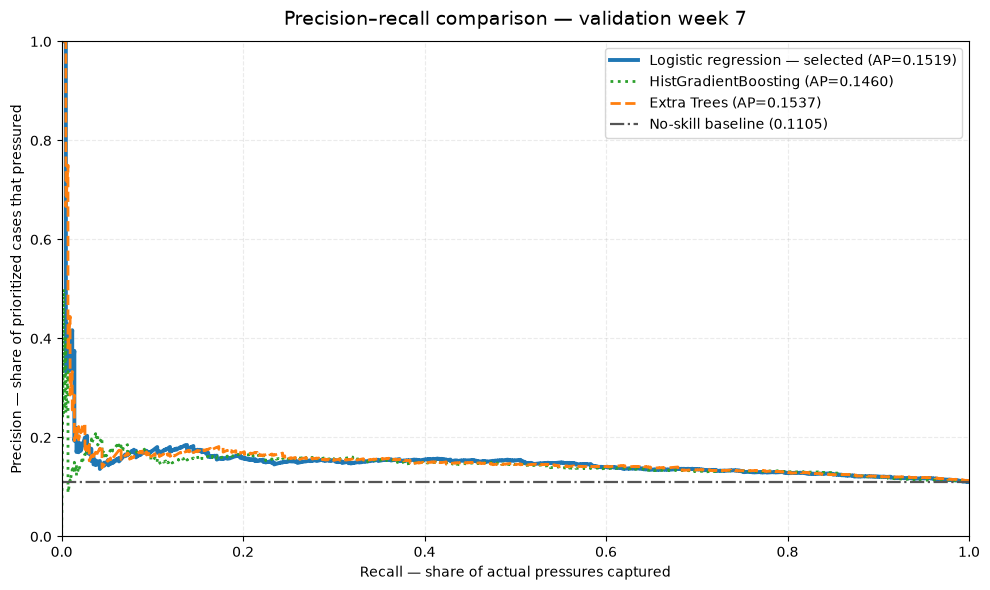

,model,curve_points,average_precision,minimum_precision,maximum_precision
0,LogisticRegression_unweighted,3866,0.151899,0.110306,1.0
1,HistGradientBoosting,3866,0.145960,0.000000,1.0
2,ExtraTrees,3866,0.153689,0.110479,1.0


No-skill prevalence: 0.110479
Curves plotted: 3
Threshold selected: False
Week 8 remains untouched.
Precision–recall visualization: PASS


In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve


model_display_names = {
    "LogisticRegression_unweighted": (
        "Logistic regression — selected"
    ),
    "ExtraTrees": "Extra Trees",
    "HistGradientBoosting": (
        "HistGradientBoosting"
    ),
}

model_plot_styles = {
    "LogisticRegression_unweighted": {
        "color": "#1f77b4",
        "linestyle": "-",
        "linewidth": 2.8,
    },
    "ExtraTrees": {
        "color": "#ff7f0e",
        "linestyle": "--",
        "linewidth": 2.0,
    },
    "HistGradientBoosting": {
        "color": "#2ca02c",
        "linestyle": ":",
        "linewidth": 2.0,
    },
}

stage7_pr_curve_frames = []
pr_curve_audit_records = []

figure, axis = plt.subplots(
    figsize=(10, 6)
)

for model_name, probabilities in (
    stage7_validation_probability_map.items()
):
    precision_values, recall_values, _ = (
        precision_recall_curve(
            y_validation,
            probabilities,
        )
    )

    model_ap = float(
        average_precision_score(
            y_validation,
            probabilities,
        )
    )

    expected_ap = float(
        validation_metrics_by_model.loc[
            model_name,
            "average_precision",
        ]
    )

    assert np.isclose(
        model_ap,
        expected_ap,
        atol=1e-12,
        rtol=0,
    )

    model_curve_data = pd.DataFrame(
        {
            "model": model_name,
            "recall": recall_values,
            "precision": precision_values,
        }
    )

    stage7_pr_curve_frames.append(
        model_curve_data
    )

    pr_curve_audit_records.append(
        {
            "model": model_name,
            "curve_points": len(
                model_curve_data
            ),
            "average_precision": model_ap,
            "minimum_precision": float(
                precision_values.min()
            ),
            "maximum_precision": float(
                precision_values.max()
            ),
        }
    )

    axis.plot(
        recall_values,
        precision_values,
        label=(
            f"{model_display_names[model_name]} "
            f"(AP={model_ap:.4f})"
        ),
        **model_plot_styles[model_name],
    )

axis.axhline(
    y=overall_validation_prevalence,
    color="#555555",
    linestyle="-.",
    linewidth=1.6,
    label=(
        "No-skill baseline "
        f"({overall_validation_prevalence:.4f})"
    ),
)

axis.set_title(
    "Precision–recall comparison — validation week 7",
    fontsize=14,
    pad=12,
)

axis.set_xlabel(
    "Recall — share of actual pressures captured"
)

axis.set_ylabel(
    "Precision — share of prioritized cases that pressured"
)

axis.set_xlim(0, 1)
axis.set_ylim(0, 1)
axis.grid(
    alpha=0.25,
    linestyle="--",
)
axis.legend(
    loc="upper right",
    frameon=True,
)

figure.tight_layout()
plt.show()

stage7_pr_curve_data = pd.concat(
    stage7_pr_curve_frames,
    ignore_index=True,
)

stage7_pr_curve_audit = pd.DataFrame(
    pr_curve_audit_records
)

assert (
    stage7_pr_curve_data["model"].nunique()
    == 3
)
assert np.isfinite(
    stage7_pr_curve_data[
        ["recall", "precision"]
    ].to_numpy()
).all()
assert "X_test" not in globals()
assert "y_test" not in globals()

display(
    stage7_pr_curve_audit.round(6)
)

print(
    "No-skill prevalence:",
    round(overall_validation_prevalence, 6),
)
print("Curves plotted: 3")
print("Threshold selected: False")
print("Week 8 remains untouched.")
print("Precision–recall visualization: PASS")

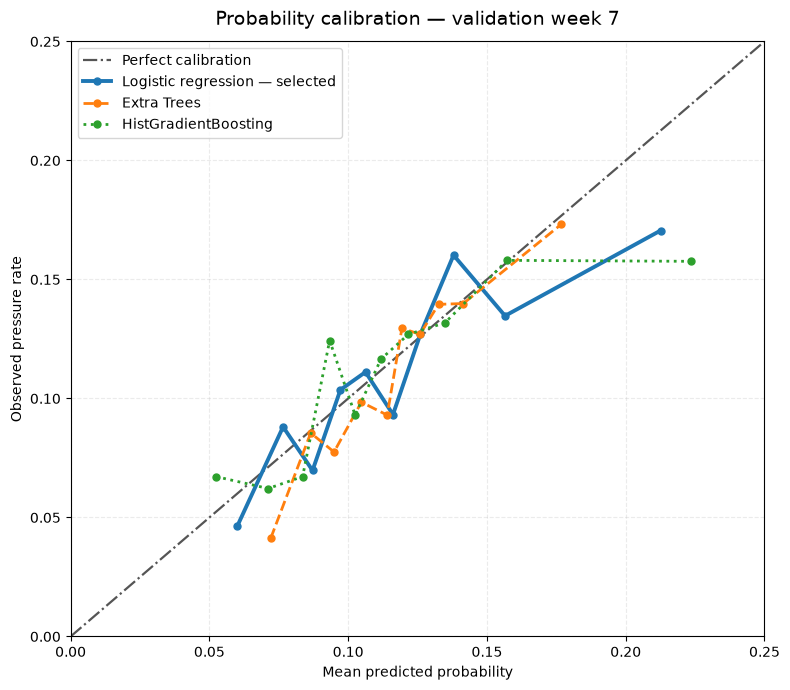

,model,mean_predicted_probability,observed_prevalence,mean_probability_bias,expected_calibration_error,maximum_calibration_gap
1,ExtraTrees,0.116837,0.110479,0.006359,0.010006,0.030779
2,HistGradientBoosting,0.115215,0.110479,0.004736,0.016052,0.065843
0,LogisticRegression_unweighted,0.117648,0.110479,0.007170,0.016372,0.041996


Calibration bins per model: 10
Calibration curves plotted: 3
Threshold selected: False
Week 8 remains untouched.
Calibration analysis: PASS


In [21]:
calibration_bin_data = (
    stage7_validation_deciles[
        [
            "model",
            "decile",
            "rows",
            "mean_predicted_probability",
            "observed_pressure_rate",
        ]
    ]
    .copy()
)

calibration_bin_data[
    "absolute_calibration_gap"
] = (
    calibration_bin_data[
        "observed_pressure_rate"
    ]
    - calibration_bin_data[
        "mean_predicted_probability"
    ]
).abs()

calibration_summary_records = []

for model_name, probability_column in (
    stage7_probability_column_map.items()
):
    model_bins = (
        calibration_bin_data.loc[
            calibration_bin_data[
                "model"
            ].eq(model_name)
        ]
        .copy()
    )

    model_probabilities = (
        stage7_validation_predictions[
            probability_column
        ].to_numpy()
    )

    expected_calibration_error = float(
        (
            model_bins["rows"]
            / model_bins["rows"].sum()
            * model_bins[
                "absolute_calibration_gap"
            ]
        ).sum()
    )

    calibration_summary_records.append(
        {
            "model": model_name,
            "mean_predicted_probability": float(
                model_probabilities.mean()
            ),
            "observed_prevalence": (
                overall_validation_prevalence
            ),
            "mean_probability_bias": float(
                model_probabilities.mean()
                - overall_validation_prevalence
            ),
            "expected_calibration_error": (
                expected_calibration_error
            ),
            "maximum_calibration_gap": float(
                model_bins[
                    "absolute_calibration_gap"
                ].max()
            ),
        }
    )

stage7_calibration_summary = pd.DataFrame(
    calibration_summary_records
)

calibration_axis_max = float(
    max(
        0.25,
        calibration_bin_data[
            [
                "mean_predicted_probability",
                "observed_pressure_rate",
            ]
        ].to_numpy().max()
        * 1.10,
    )
)

figure, axis = plt.subplots(
    figsize=(8, 7)
)

axis.plot(
    [0, calibration_axis_max],
    [0, calibration_axis_max],
    color="#555555",
    linestyle="-.",
    linewidth=1.6,
    label="Perfect calibration",
)

for model_name in (
    stage7_probability_column_map
):
    model_bins = (
        calibration_bin_data.loc[
            calibration_bin_data[
                "model"
            ].eq(model_name)
        ]
        .sort_values(
            "mean_predicted_probability"
        )
    )

    axis.plot(
        model_bins[
            "mean_predicted_probability"
        ],
        model_bins[
            "observed_pressure_rate"
        ],
        marker="o",
        markersize=5,
        label=model_display_names[model_name],
        **model_plot_styles[model_name],
    )

axis.set_title(
    "Probability calibration — validation week 7",
    fontsize=14,
    pad=12,
)

axis.set_xlabel(
    "Mean predicted probability"
)

axis.set_ylabel(
    "Observed pressure rate"
)

axis.set_xlim(
    0,
    calibration_axis_max,
)
axis.set_ylim(
    0,
    calibration_axis_max,
)

axis.grid(
    alpha=0.25,
    linestyle="--",
)

axis.legend(
    loc="upper left",
    frameon=True,
)

figure.tight_layout()
plt.show()

assert len(calibration_bin_data) == 30
assert (
    calibration_bin_data
    .groupby("model")
    .size()
    .eq(10)
    .all()
)
assert len(stage7_calibration_summary) == 3
assert np.isfinite(
    stage7_calibration_summary[
        [
            "mean_predicted_probability",
            "observed_prevalence",
            "mean_probability_bias",
            "expected_calibration_error",
            "maximum_calibration_gap",
        ]
    ].to_numpy()
).all()
assert "X_test" not in globals()
assert "y_test" not in globals()

display(
    stage7_calibration_summary.sort_values(
        "expected_calibration_error"
    ).round(6)
)

print("Calibration bins per model: 10")
print("Calibration curves plotted: 3")
print("Threshold selected: False")
print("Week 8 remains untouched.")
print("Calibration analysis: PASS")

In [22]:
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"

assert REPORTS_DIR.is_dir()
assert MODELS_DIR.is_dir()

stage7_temporal_cv_results_artifact = (
    pd.concat(
        [
            stage7_cv_fold_results,
            stage6_cv_fold_results,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "model",
            "configuration_id",
            "validation_week",
        ]
    )
    .reset_index(drop=True)
)

stage7_temporal_cv_summary_artifact = (
    pd.concat(
        [
            stage7_cv_summary,
            pd.DataFrame(
                [stage6_cv_summary]
            ),
        ],
        ignore_index=True,
        sort=False,
    )
    .merge(
        configuration_table,
        on=[
            "model",
            "configuration_id",
        ],
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        [
            "model",
            "mean_average_precision",
        ],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

stage7_candidate_results_artifact = (
    stage7_validation_comparison
    .merge(
        stage7_model_selection[
            [
                "model",
                "temporal_cv_mean_ap",
                "selected_stage7_candidate",
                "decision",
            ]
        ],
        on="model",
        how="left",
        validate="one_to_one",
    )
    .sort_values("ap_rank")
    .reset_index(drop=True)
)

stage7_artifact_paths = {
    "selected_model": (
        MODELS_DIR
        / "stage7_selected_model.joblib"
    ),
    "temporal_cv_results": (
        REPORTS_DIR
        / "stage7_temporal_cv_results.csv"
    ),
    "temporal_cv_summary": (
        REPORTS_DIR
        / "stage7_temporal_cv_summary.csv"
    ),
    "candidate_results": (
        REPORTS_DIR
        / "stage7_candidate_results.csv"
    ),
    "bootstrap_summary": (
        REPORTS_DIR
        / "stage7_bootstrap_summary.csv"
    ),
    "validation_predictions": (
        REPORTS_DIR
        / "stage7_validation_predictions.parquet"
    ),
    "validation_deciles": (
        REPORTS_DIR
        / "stage7_validation_deciles.csv"
    ),
    "calibration_summary": (
        REPORTS_DIR
        / "stage7_calibration_summary.csv"
    ),
}

joblib.dump(
    selected_stage7_pipeline,
    stage7_artifact_paths[
        "selected_model"
    ],
)

stage7_temporal_cv_results_artifact.to_csv(
    stage7_artifact_paths[
        "temporal_cv_results"
    ],
    index=False,
)

stage7_temporal_cv_summary_artifact.to_csv(
    stage7_artifact_paths[
        "temporal_cv_summary"
    ],
    index=False,
    na_rep="",
)

stage7_candidate_results_artifact.to_csv(
    stage7_artifact_paths[
        "candidate_results"
    ],
    index=False,
    na_rep="",
)

bootstrap_comparison_summary.to_csv(
    stage7_artifact_paths[
        "bootstrap_summary"
    ],
    index=False,
)

stage7_validation_predictions.to_parquet(
    stage7_artifact_paths[
        "validation_predictions"
    ],
    index=False,
)

stage7_validation_deciles.to_csv(
    stage7_artifact_paths[
        "validation_deciles"
    ],
    index=False,
)

stage7_calibration_summary.to_csv(
    stage7_artifact_paths[
        "calibration_summary"
    ],
    index=False,
)

reloaded_stage7_pipeline = joblib.load(
    stage7_artifact_paths[
        "selected_model"
    ]
)

reloaded_stage7_feature_order = (
    reloaded_stage7_pipeline
    .feature_names_in_
    .tolist()
)

reloaded_stage7_probability_matrix = (
    reloaded_stage7_pipeline.predict_proba(
        X_validation.loc[
            :,
            reloaded_stage7_feature_order,
        ]
    )
)

reloaded_stage7_classes = np.asarray(
    reloaded_stage7_pipeline.classes_
)

reloaded_positive_matches = np.flatnonzero(
    reloaded_stage7_classes == 1
)

assert len(reloaded_positive_matches) == 1

reloaded_positive_index = int(
    reloaded_positive_matches[0]
)

reloaded_stage7_probabilities = (
    reloaded_stage7_probability_matrix[
        :,
        reloaded_positive_index,
    ]
)

reloaded_probability_difference = float(
    np.max(
        np.abs(
            reloaded_stage7_probabilities
            - selected_stage7_validation_probabilities
        )
    )
)

stage7_artifact_audit = pd.DataFrame(
    [
        {
            "artifact": artifact_name,
            "exists": artifact_path.is_file(),
            "size_bytes": (
                artifact_path.stat().st_size
                if artifact_path.is_file()
                else 0
            ),
            "path": str(artifact_path),
        }
        for artifact_name, artifact_path
        in stage7_artifact_paths.items()
    ]
)

assert len(stage7_artifact_audit) == 8
assert stage7_artifact_audit[
    "exists"
].all()
assert (
    stage7_artifact_audit[
        "size_bytes"
    ] > 0
).all()

assert len(
    stage7_temporal_cv_results_artifact
) == 75

assert len(
    stage7_temporal_cv_summary_artifact
) == 25

assert len(
    stage7_candidate_results_artifact
) == 3

assert len(
    stage7_validation_predictions
) == 3_865

assert len(
    stage7_validation_deciles
) == 30

assert reloaded_probability_difference <= 1e-15
assert "X_test" not in globals()
assert "y_test" not in globals()

display(stage7_artifact_audit)

print(
    "Artifacts written:",
    len(stage7_artifact_audit),
)
print(
    "Reloaded probability difference:",
    reloaded_probability_difference,
)
print("Threshold selected: False")
print("Week 8 remains untouched.")
print("Stage 7 artifact persistence: PASS")

,artifact,exists,size_bytes,path
0,selected_model,True,9649,C:\Users\yvett\OneDrive\Documentos\Francisco F...
1,temporal_cv_results,True,18656,C:\Users\yvett\OneDrive\Documentos\Francisco F...
2,temporal_cv_summary,True,5930,C:\Users\yvett\OneDrive\Documentos\Francisco F...
3,candidate_results,True,1396,C:\Users\yvett\OneDrive\Documentos\Francisco F...
4,bootstrap_summary,True,472,C:\Users\yvett\OneDrive\Documentos\Francisco F...
5,validation_predictions,True,129661,C:\Users\yvett\OneDrive\Documentos\Francisco F...
6,validation_deciles,True,4841,C:\Users\yvett\OneDrive\Documentos\Francisco F...
7,calibration_summary,True,498,C:\Users\yvett\OneDrive\Documentos\Francisco F...


Artifacts written: 8
Reloaded probability difference: 0.0
Threshold selected: False
Week 8 remains untouched.
Stage 7 artifact persistence: PASS


In [23]:
quality_checks = [
    {
        "check_id": "M7-01",
        "area": "Development scope",
        "passed": (
            set(
                development_df[
                    "actual_week"
                ].unique()
            )
            == set(DEVELOPMENT_WEEKS)
            and 8 not in development_df[
                "actual_week"
            ].unique()
        ),
        "result": (
            "Only actual weeks 1–7 were "
            "materialized."
        ),
        "decision": (
            "Preserve week 8 for final testing."
        ),
    },
    {
        "check_id": "M7-02",
        "area": "Approved split",
        "passed": (
            X_train.shape == (27_950, 51)
            and X_validation.shape
            == (3_865, 51)
            and len(shared_plays) == 0
        ),
        "result": (
            "Train has 27,950 rows; validation "
            "has 3,865; shared plays = 0."
        ),
        "decision": (
            "Keep weeks 1–6 for train and "
            "week 7 for validation."
        ),
    },
    {
        "check_id": "M7-03",
        "area": "Feature contract",
        "passed": (
            len(numeric_features) == 50
            and len(categorical_features) == 1
            and len(feature_columns) == 51
            and forbidden_predictors == []
        ),
        "result": (
            "50 numeric and 1 categorical "
            "predictor; no forbidden features."
        ),
        "decision": (
            "Preserve the approved Stage 6 "
            "feature contract."
        ),
    },
    {
        "check_id": "M7-04",
        "area": "Temporal tuning",
        "passed": (
            len(temporal_cv_splits) == 3
            and temporal_cv_audit[
                "validation_week"
            ].tolist() == [4, 5, 6]
            and temporal_cv_audit[
                "shared_plays"
            ].sum() == 0
        ),
        "result": (
            "Three expanding folds validated "
            "weeks 4, 5, and 6."
        ),
        "decision": (
            "Use only past weeks to predict "
            "each tuning week."
        ),
    },
    {
        "check_id": "M7-05",
        "area": "Search budget",
        "passed": (
            stage7_cv_summary[
                "configuration_id"
            ].nunique() == 24
            and len(
                stage7_cv_fold_results
            ) == 72
        ),
        "result": (
            "24 configurations and 72 "
            "fold evaluations completed."
        ),
        "decision": (
            "Keep the search controlled and "
            "reproducible."
        ),
    },
    {
        "check_id": "M7-06",
        "area": "Locked configurations",
        "passed": (
            set(
                stage7_best_cv_configurations[
                    "configuration_id"
                ]
            )
            == {
                "ExtraTrees_C10",
                "HistGradientBoosting_C07",
            }
        ),
        "result": (
            "ExtraTrees_C10 and "
            "HistGradientBoosting_C07 locked."
        ),
        "decision": (
            "Do not alter hyperparameters after "
            "week 7 evaluation."
        ),
    },
    {
        "check_id": "M7-07",
        "area": "Validation comparison",
        "passed": (
            len(
                stage7_validation_comparison
            ) == 3
            and stage7_validation_comparison[
                "rows"
            ].eq(3_865).all()
            and stage7_validation_comparison[
                "positives"
            ].eq(427).all()
        ),
        "result": (
            "Three models evaluated on the same "
            "3,865 rows and 427 positives."
        ),
        "decision": (
            "Compare candidates with identical "
            "validation observations."
        ),
    },
    {
        "check_id": "M7-08",
        "area": "Candidate selection",
        "passed": (
            stage7_model_selection[
                "selected_stage7_candidate"
            ].sum() == 1
            and selected_stage7_candidate_name
            == "LogisticRegression_unweighted"
        ),
        "result": (
            "Exactly one candidate selected: "
            "unweighted logistic regression."
        ),
        "decision": (
            "Retain the simpler model because "
            "advanced gains were not stable."
        ),
    },
    {
        "check_id": "M7-09",
        "area": "Uncertainty analysis",
        "passed": (
            len(bootstrap_deltas_df) == 2_000
            and len(play_row_indices) == 913
            and (
                ap_bootstrap_result[
                    "ci_lower_95"
                ]
                <= 0
                <= ap_bootstrap_result[
                    "ci_upper_95"
                ]
            )
        ),
        "result": (
            "2,000 play-cluster bootstrap "
            "iterations; AP interval includes 0."
        ),
        "decision": (
            "Do not claim a reliable Extra Trees "
            "improvement."
        ),
    },
    {
        "check_id": "M7-10",
        "area": "Prediction traceability",
        "passed": (
            len(
                stage7_validation_predictions
            ) == 3_865
            and duplicate_prediction_keys == 0
            and stage7_validation_predictions[
                prediction_probability_columns
            ].isna().sum().sum() == 0
        ),
        "result": (
            "3,865 traceable predictions; "
            "duplicate keys = 0; missing = 0."
        ),
        "decision": (
            "Preserve player-play keys with all "
            "candidate probabilities."
        ),
    },
    {
        "check_id": "M7-11",
        "area": "Decile analysis",
        "passed": (
            len(
                stage7_validation_deciles
            ) == 30
            and decile_counts[
                "deciles"
            ].eq(10).all()
            and decile_counts[
                "total_pressures"
            ].eq(427).all()
        ),
        "result": (
            "Ten deciles per model and 427 "
            "positives preserved."
        ),
        "decision": (
            "Use deciles only for ranking "
            "diagnostics, not thresholding."
        ),
    },
    {
        "check_id": "M7-12",
        "area": "Probability diagnostics",
        "passed": (
            len(
                stage7_calibration_summary
            ) == 3
            and len(
                stage7_pr_curve_audit
            ) == 3
            and len(
                calibration_bin_data
            ) == 30
        ),
        "result": (
            "PR and ten-bin calibration analyses "
            "completed for three models."
        ),
        "decision": (
            "Retain AP as primary; use "
            "calibration as supporting evidence."
        ),
    },
    {
        "check_id": "M7-13",
        "area": "Serialization",
        "passed": (
            reloaded_probability_difference
            <= 1e-15
        ),
        "result": (
            "Reloaded pipeline reproduced "
            "probabilities exactly."
        ),
        "decision": (
            "Persist the complete selected "
            "pipeline."
        ),
    },
    {
        "check_id": "M7-14",
        "area": "Threshold policy",
        "passed": (
            "selected_threshold"
            not in globals()
        ),
        "result": (
            "No classification threshold was "
            "selected."
        ),
        "decision": (
            "Defer precision, recall, F1, and "
            "confusion matrix decisions."
        ),
    },
    {
        "check_id": "M7-15",
        "area": "Test protection",
        "passed": (
            "X_test" not in globals()
            and "y_test" not in globals()
            and 8 not in development_df[
                "actual_week"
            ].unique()
        ),
        "result": (
            "X_test and y_test do not exist; "
            "week 8 was not materialized."
        ),
        "decision": (
            "Keep test completely untouched."
        ),
    },
    {
        "check_id": "M7-16",
        "area": "Artifacts",
        "passed": (
            len(stage7_artifact_audit) == 8
            and stage7_artifact_audit[
                "exists"
            ].all()
            and (
                stage7_artifact_audit[
                    "size_bytes"
                ] > 0
            ).all()
        ),
        "result": (
            "Eight pre-quality artifacts exist "
            "and are non-empty."
        ),
        "decision": (
            "Add the quality report as the ninth "
            "Stage 7 artifact."
        ),
    },
]

stage7_quality_report = pd.DataFrame(
    quality_checks
)

stage7_quality_report["status"] = np.where(
    stage7_quality_report["passed"],
    "PASS",
    "FAIL",
)

stage7_quality_report = (
    stage7_quality_report[
        [
            "check_id",
            "area",
            "status",
            "result",
            "decision",
        ]
    ]
)

stage7_quality_report_path = (
    REPORTS_DIR
    / "stage7_quality_report.csv"
)

stage7_quality_report.to_csv(
    stage7_quality_report_path,
    index=False,
)

stage7_artifact_paths[
    "quality_report"
] = stage7_quality_report_path

final_stage7_artifact_audit = pd.DataFrame(
    [
        {
            "artifact": artifact_name,
            "exists": artifact_path.is_file(),
            "size_bytes": (
                artifact_path.stat().st_size
                if artifact_path.is_file()
                else 0
            ),
            "path": str(artifact_path),
        }
        for artifact_name, artifact_path
        in stage7_artifact_paths.items()
    ]
)

failed_quality_checks = (
    stage7_quality_report.loc[
        stage7_quality_report[
            "status"
        ].ne("PASS")
    ]
)

display(stage7_quality_report)
display(final_stage7_artifact_audit)

if not failed_quality_checks.empty:
    raise AssertionError(
        "Failed Stage 7 checks: "
        f"{failed_quality_checks['check_id'].tolist()}"
    )

assert len(stage7_quality_report) == 16
assert len(final_stage7_artifact_audit) == 9
assert final_stage7_artifact_audit[
    "exists"
].all()
assert (
    final_stage7_artifact_audit[
        "size_bytes"
    ] > 0
).all()

print("Quality checks passed: 16/16")
print("Final Stage 7 artifacts: 9")
print("Threshold selected: False")
print("Week 8 remains untouched.")
print("Stage 7 computational quality report: PASS")

,check_id,area,status,result,decision
0,M7-01,Development scope,PASS,Only actual weeks 1–7 were materialized.,Preserve week 8 for final testing.
1,M7-02,Approved split,PASS,"Train has 27,950 rows; validation has 3,865; s...",Keep weeks 1–6 for train and week 7 for valida...
2,M7-03,Feature contract,PASS,50 numeric and 1 categorical predictor; no for...,Preserve the approved Stage 6 feature contract.
3,M7-04,Temporal tuning,PASS,"Three expanding folds validated weeks 4, 5, an...",Use only past weeks to predict each tuning week.
4,M7-05,Search budget,PASS,24 configurations and 72 fold evaluations comp...,Keep the search controlled and reproducible.
5,M7-06,Locked configurations,PASS,ExtraTrees_C10 and HistGradientBoosting_C07 lo...,Do not alter hyperparameters after week 7 eval...
6,M7-07,Validation comparison,PASS,"Three models evaluated on the same 3,865 rows ...",Compare candidates with identical validation o...
7,M7-08,Candidate selection,PASS,Exactly one candidate selected: unweighted log...,Retain the simpler model because advanced gain...
8,M7-09,Uncertainty analysis,PASS,"2,000 play-cluster bootstrap iterations; AP in...",Do not claim a reliable Extra Trees improvement.
9,M7-10,Prediction traceability,PASS,"3,865 traceable predictions; duplicate keys = ...",Preserve player-play keys with all candidate p...


,artifact,exists,size_bytes,path
0,selected_model,True,9649,C:\Users\yvett\OneDrive\Documentos\Francisco F...
1,temporal_cv_results,True,18656,C:\Users\yvett\OneDrive\Documentos\Francisco F...
2,temporal_cv_summary,True,5930,C:\Users\yvett\OneDrive\Documentos\Francisco F...
3,candidate_results,True,1396,C:\Users\yvett\OneDrive\Documentos\Francisco F...
4,bootstrap_summary,True,472,C:\Users\yvett\OneDrive\Documentos\Francisco F...
5,validation_predictions,True,129661,C:\Users\yvett\OneDrive\Documentos\Francisco F...
6,validation_deciles,True,4841,C:\Users\yvett\OneDrive\Documentos\Francisco F...
7,calibration_summary,True,498,C:\Users\yvett\OneDrive\Documentos\Francisco F...
8,quality_report,True,2261,C:\Users\yvett\OneDrive\Documentos\Francisco F...


Quality checks passed: 16/16
Final Stage 7 artifacts: 9
Threshold selected: False
Week 8 remains untouched.
Stage 7 computational quality report: PASS


# Stage 7 Conclusions

## Controlled model comparison

Two nonlinear model families were evaluated against the selected Stage 6 logistic-regression baseline:

| Model | Validation AP | ROC-AUC | Log Loss |
|---|---:|---:|---:|
| Extra Trees — `C10` | 0.153689 | 0.602314 | 0.341647 |
| Logistic regression | 0.151899 | 0.600006 | 0.342382 |
| HistGradientBoosting — `C07` | 0.145960 | 0.595577 | 0.343728 |

Extra Trees obtained the best validation point estimates. Its absolute AP improvement over logistic regression was `0.001790`, equivalent to a relative improvement of approximately `1.18%`.

However, the improvement was not temporally consistent:

- Week 4 AP gain: `+0.002037`.
- Week 5 AP gain: approximately `-0.000016`.
- Week 6 AP gain: `-0.001435`.
- Temporal mean AP differed by only `0.000195` in favor of Extra Trees.

## Uncertainty analysis

A paired bootstrap with 2,000 iterations was performed by resampling all 913 validation plays as complete groups.

For the Extra Trees AP gain:

- Point estimate: `0.001790`.
- Bootstrap mean: `0.001660`.
- 95% interval: `[-0.011327, 0.014929]`.
- Extra Trees produced a positive AP difference in 59.6% of bootstrap samples.

The interval includes zero and contains both meaningful losses and gains. Therefore, the observed improvement cannot be considered sufficiently reliable.

The corresponding intervals for ROC-AUC gain and Log Loss reduction also included zero.

## Ranking and calibration diagnostics

The models produced highly overlapping precision-recall curves.

Within the highest-probability validation decile:

- Extra Trees identified 67 pressures.
- Logistic regression identified 66 pressures.
- HistGradientBoosting identified 61 pressures.

The selected logistic model achieved:

- Observed top-decile pressure rate: `17.054%`.
- Top-decile lift: `1.544×`.
- Positive cases captured in the top decile: `15.457%`.

Extra Trees showed a lower ten-bin calibration error than logistic regression (`0.010006` versus `0.016372`). This difference was treated as supporting evidence rather than a new post-hoc selection criterion. Its predeclared Log Loss improvement was also small and uncertain under play-cluster bootstrap.

## Selected Stage 7 candidate

The selected candidate remains:

`LogisticRegression_unweighted`

The more complex Extra Trees model was not selected because its performance improvement was marginal, inconsistent across temporal folds, and unsupported by the uncertainty analysis.

Retaining logistic regression provides:

- Comparable predictive performance.
- Greater interpretability.
- Simpler deployment and reproducibility.
- Existing coefficient and odds-ratio explanations.
- Better defensibility when presenting why additional complexity was rejected.

This is a model-selection conclusion, not a claim that logistic regression is universally superior to Extra Trees.

## Limitations

- Predictive separation remains moderate, with validation ROC-AUC close to 0.60.
- Decile ordering is not perfectly monotonic.
- Some position categories may be absent from early temporal folds.
- Observed feature relationships are predictive associations and not causal effects.
- Final generalization performance remains unknown until the untouched test period is evaluated.

## Stage closure

- Twenty-four advanced configurations were evaluated across three temporal folds.
- Exactly one candidate was selected.
- No classification threshold was chosen.
- No `X_test` or `y_test` matrix was created.
- Actual NFL week 8 remains untouched.
- The serialized pipeline reproduces validation probabilities exactly.
- All 16 Stage 7 computational quality controls passed.
- Nine Stage 7 artifacts were generated.

The next stage must define the operating threshold using validation data, lock every remaining decision, and only then proceed to the one-time final evaluation on week 8.